# DPO-обучение
Ноутбук реализует пайплайн генерации художественных шаржей по фотографиям людей и дообучения Stable Diffusion методом Direct Preference Optimization. Исходное фото проходит через биометрический анализ InsightFace и геометрический анализ MediaPipe, после чего вычисляется вектор преувеличения относительно среднего лица датасета и применяется варп-деформация пикселей. Деформированное изображение вместе с картой контуров Canny и эмбеддингом лица подаётся в Stable Diffusion с ControlNet и IP-Adapter FaceID, который генерирует два варианта шаржа с разными seed. Полученная пара оценивается мультимодальной моделью-судьёй, формирующей разметку chosen/rejected для последующего DPO-обучения LoRA-адаптера на нескольких GPU.

In [1]:
import subprocess, sys

packages = [
    "insightface",
    "onnxruntime-gpu",
    "diffusers>=0.27.0",
    "transformers",
    "accelerate",
    "opencv-python-headless",
    "Pillow",
    "matplotlib",
    "peft",
    "mediapipe==0.10.35",   # уже установлена, явно фиксируем версию
    "tqdm",
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("✅ Все пакеты установлены")

✅ Все пакеты установлены


In [2]:
import os
import gc
import json
import random
import warnings
import urllib.request
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

# Подавляем мусорные логи ДО импорта mediapipe
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["GLOG_minloglevel"]     = "3"

# MediaPipe 0.10.35 — только tasks API, solutions API удалён
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# mp_face_mesh НЕ импортируем — в 0.10.35 его нет физически
# Вместо него используем захардкоженные константы (см. ячейку ниже)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ─── Пути ─────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
DATASET_DIR  = NOTEBOOK_DIR.parent / "dataset" / "Humans"
OUTPUT_DIR   = NOTEBOOK_DIR / "dpo_dataset"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ─── Гиперпараметры SD ────────────────────────────────────────────────────────
CROP_SIZE          = 512
DENOISE_STRENGTH   = 0.85   # было 0.75 → больше свободы SD
GUIDANCE_SCALE     = 9.0    # было 7.5  → строже следует промпту
IP_ADAPTER_SCALE   = 0.35   # было 0.5  → меньше зависимость от фото лица
LORA_SCALE         = 0.4    # было 0.6  → меньше влияние LoRA
NUM_STEPS          = 35     # было 30   → чуть больше шагов для качества
SEED_A             = 67
SEED_B             = 999
CANNY_LO           = 60     # было 80   → больше контуров варпа
CANNY_HI           = 150    # было 200  → улавливаем мелкие деформации
CONTROLNET_WEIGHT  = 0.6    # было 0.8  → ControlNet менее жёсткий
CONTROLNET_START   = 0.0
CONTROLNET_END     = 0.65   # было 0.8  → раньше отпускаем контуры

print(f"✅ Импорты загружены")
print(f"   MediaPipe: {mp.__version__}")
print(f"📁 Датасет : {DATASET_DIR}")
print(f"📁 Выходная: {OUTPUT_DIR}")
print(f"🖥  CUDA    : {torch.cuda.is_available()} | "
      f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

✅ Импорты загружены
   MediaPipe: 0.10.35
📁 Датасет : /home/kseno/CaricatureGenerator/dataset/Humans
📁 Выходная: /home/kseno/CaricatureGenerator/noteboks/dpo_dataset
🖥  CUDA    : True | Tesla V100-SXM2-32GB


In [3]:
# ─── Захардкоженные топологические константы MediaPipe Face Mesh ──────────────
#
# Источник: официальный репозиторий Google MediaPipe
# https://github.com/google/mediapipe/blob/master/mediapipe/python/solutions/face_mesh_connections.py
#
# Эти константы определяются ТОПОЛОГИЕЙ НЕЙРОСЕТЕВОЙ МОДЕЛИ (468/478 точек),
# а не версией Python-пакета. Они не изменятся никогда, пока используется
# та же модель face_landmarker.task.
# Поэтому захардкодить их — абсолютно корректное решение.

_FACEMESH_LIPS = frozenset([
    (61, 146), (146, 91), (91, 181), (181, 84), (84, 17),
    (17, 314), (314, 405), (405, 320), (320, 307), (307, 375),
    (375, 321), (61, 185), (185, 40), (40, 39), (39, 37),
    (37, 0), (0, 267), (267, 269), (269, 270), (270, 409),
    (409, 291), (78, 95), (95, 88), (88, 178), (178, 87),
    (87, 14), (14, 317), (317, 402), (402, 318), (318, 324),
    (324, 308), (78, 191), (191, 80), (80, 81), (81, 82),
    (82, 13), (13, 312), (312, 311), (311, 310), (310, 415),
    (415, 308),
])

_FACEMESH_LEFT_EYE = frozenset([
    (263, 249), (249, 390), (390, 373), (373, 374),
    (374, 380), (380, 381), (381, 382), (382, 362),
    (263, 466), (466, 388), (388, 387), (387, 386),
    (386, 385), (385, 384), (384, 398), (398, 362),
])

_FACEMESH_LEFT_EYEBROW = frozenset([
    (276, 283), (283, 282), (282, 295), (295, 285),
    (300, 293), (293, 334), (334, 296), (296, 336),
])

_FACEMESH_RIGHT_EYE = frozenset([
    (33, 7),   (7, 163),  (163, 144), (144, 145),
    (145, 153),(153, 154),(154, 155), (155, 133),
    (33, 246), (246, 161),(161, 160), (160, 159),
    (159, 158),(158, 157),(157, 173), (173, 133),
])

_FACEMESH_RIGHT_EYEBROW = frozenset([
    (46, 53), (53, 52), (52, 65), (65, 55),
    (70, 63), (63, 105),(105, 66), (66, 107),
])

_FACEMESH_FACE_OVAL = frozenset([
    (10, 338),  (338, 297), (297, 332), (332, 284),
    (284, 251), (251, 389), (389, 356), (356, 454),
    (454, 323), (323, 361), (361, 288), (288, 397),
    (397, 365), (365, 379), (379, 378), (378, 400),
    (400, 377), (377, 152), (152, 148), (148, 176),
    (176, 149), (149, 150), (150, 136), (136, 172),
    (172, 58),  (58, 132),  (132, 93),  (93, 234),
    (234, 127), (127, 162), (162, 21),  (21, 54),
    (54, 103),  (103, 67),  (67, 109),  (109, 10),
])

# Нос — нет именованной константы в оригинальном MediaPipe,
# используются фиксированные индексы из анатомической разметки
_FACEMESH_NOSE = frozenset([
    (168, 6), (6, 197), (197, 195), (195, 5),
    (5, 4),   (4, 1),   (1, 19),   (19, 94),
    (94, 2),  (98, 97), (97, 2),   (326, 327),
    (327, 2),
])

print("✅ Константы Face Mesh загружены")
print(f"   LIPS        : {len(_FACEMESH_LIPS)} соединений")
print(f"   LEFT_EYE    : {len(_FACEMESH_LEFT_EYE)} соединений")
print(f"   RIGHT_EYE   : {len(_FACEMESH_RIGHT_EYE)} соединений")
print(f"   FACE_OVAL   : {len(_FACEMESH_FACE_OVAL)} соединений")

✅ Константы Face Mesh загружены
   LIPS        : 41 соединений
   LEFT_EYE    : 16 соединений
   RIGHT_EYE   : 16 соединений
   FACE_OVAL   : 36 соединений


In [4]:
from typing import Dict, Optional

class MediaPipeFaceAggregator:
    """
    Агрегатор лиц с использованием MediaPipe Face Landmarker (478 точек)
    Новая версия с mp.tasks API
    """
    
    def __init__(self, model_path: str = "artifacts/pretrained_models/face_landmarker.task",  mean_face_path: Optional[str] = None):
        # Скачиваем модель если её нет
        model_path = os.path.join(os.path.abspath(".."), model_path)
        if not os.path.exists(model_path):
            self._download_model(model_path)
        
        # Инициализация детектора MediaPipe Tasks API
        base_options = python.BaseOptions(model_asset_path=model_path)
        options = vision.FaceLandmarkerOptions(
            base_options=base_options,
            output_face_blendshapes=False,
            output_facial_transformation_matrixes=False,
            num_faces=1,
            min_face_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )
        self.detector = vision.FaceLandmarker.create_from_options(options)
        
        # Внутренние хранилища для режима накопления базы данных
        self.all_landmarks = []          # нормализованные (N, 478, 2)
        self.all_original_landmarks = [] # в пикселях (N, 478, 2)
        self.all_features = []           # признаки лиц (N, M)
        
        # Поле для хранения кэшированной статистики
        self._cached_stats = None
        
        # Индексы ключевых точек MediaPipe (внутренний маппинг)
        self.indices = {
            'face_contour': [10, 338, 297, 332, 284, 251, 389, 356, 454, 23],
            'forehead_top': [10, 338, 297],
            'forehead_bottom': [151, 108, 69],
            'left_eyebrow_upper': [70, 63, 105, 66, 107],
            'left_eyebrow_lower': [46, 53, 52, 65, 55],
            'right_eyebrow_upper': [336, 296, 334, 293, 300],
            'right_eyebrow_lower': [282, 283, 285, 295, 282],
            'left_eye': [33, 133, 157, 158, 159, 160, 161, 173],
            'right_eye': [362, 263, 387, 386, 385, 384, 398, 466],
            'nose_tip': [1, 2, 98, 327, 326, 94],
            'nose_bridge': [168, 6, 195, 5, 4],
            'nose_base': [94, 97, 2, 326, 327, 294],
            'mouth_outer': [61, 146, 91, 181, 84, 17, 314, 405, 320, 307, 375, 321],
            'mouth_corners': [61, 291],
            'chin': [152, 148, 149, 150, 136, 172, 138, 135, 169],
            'left_cheekbone': [50, 101, 100, 117, 118],
            'right_cheekbone': [280, 331, 330, 348, 347],
            'jawline': [172, 136, 150, 149, 148, 152, 377, 378, 379, 365],
        }
        
        self.feature_names = [
            'left_eye_width', 'left_eye_height', 'right_eye_width', 'right_eye_height',
            'nose_width', 'nose_height', 'mouth_width', 'mouth_height',
            'left_eyebrow_thickness', 'right_eyebrow_thickness', 'jaw_width',
            'smile_angle', 'face_ratio'
        ]
        
        # Если передан путь к файлу статистики, загружаем его моментально
        if mean_face_path is not None:
            self.load_mean_face(mean_face_path)

    def _download_model(self, model_path: str):
        """Скачивает модель FaceLandmarker"""
        url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
        print(f"Скачивание модели {model_path}...")
        urllib.request.urlretrieve(url, model_path)
        print("✅ Модель скачана")

    def load_mean_face(self, filepath: str):
        """Загружает готовую предобработанную статистику выборки из JSON"""
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Файл статистики не найден по пути: {filepath}")
        
        with open(filepath, 'r') as f:
            data = json.load(f)
        
        # Восстанавливаем матрицы в формат numpy массивов
        self._cached_stats = {
            'mean_landmarks': np.array(data['mean_landmarks'], dtype=np.float32),
            'median_landmarks': np.array(data.get('median_landmarks', data['mean_landmarks']), dtype=np.float32),
            'std_landmarks': np.array(data['std_landmarks'], dtype=np.float32),
            'mean_features': np.array(data['mean_features'], dtype=np.float32),
            'median_features': np.array(data.get('median_features', data['mean_features']), dtype=np.float32),
            'std_features': np.array(data['std_features'], dtype=np.float32),
            'feature_names': data['feature_names'],
            'num_samples': data['num_samples']
        }
        self.feature_names = data['feature_names']
        print(f"Статистика базы успешно импортирована из {filepath} (Выборка: {data['num_samples']} лиц). Расчет датасета пропущен!")

    def extract_landmarks_from_image(self, image_path: str) -> np.ndarray:
        """Извлекает 478 точек из изображения через MediaPipe"""
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Не удалось загрузить изображение: {image_path}")
        
        h, w = image.shape[:2]
        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        elif image.shape[2] == 4:
            image = cv2.cvtColor(image, cv2.COLOR_BGRA2RGB)
        else: 
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image)
        result = self.detector.detect(mp_image)
        
        if not result.face_landmarks:
            raise ValueError(f"Лицо не найдено на кадре: {image_path}")
        
        landmarks_pixels = [[int(lm.x * w), int(lm.y * h)] for lm in result.face_landmarks[0]]
        return np.array(landmarks_pixels)
    
    def normalize_landmarks(self, landmarks: np.ndarray) -> np.ndarray:
        """Нормализация landmarks: центрирование и масштабирование относительно зрачков"""
        left_eye = landmarks[33]
        right_eye = landmarks[263]
        
        eye_center = (left_eye + right_eye) / 2
        eye_distance = np.linalg.norm(left_eye - right_eye)
        
        if eye_distance > 0:
            return (landmarks - eye_center) / eye_distance
        return landmarks - eye_center
    
    def _calculate_angle(self, p1: np.ndarray, p2: np.ndarray, p3: np.ndarray) -> float:
        """Вычисляет угол между тремя точками в градусах"""
        v1 = p1 - p2
        v2 = p3 - p2
        cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-6)
        return float(np.degrees(np.arccos(np.clip(cos_angle, -1, 1))))
    
    def extract_face_features(self, landmarks: np.ndarray, print_output: bool = False) -> Dict[str, float]:
        """Извлекает инвариантные геометрические признаки лица (устойчивые к наклонам)"""
        features = {}
        pts = self.normalize_landmarks(landmarks) if np.max(landmarks) > 10 else landmarks

        face_width = np.linalg.norm(pts[454] - pts[234]) 
        face_height = np.linalg.norm(pts[152] - pts[10]) 

        # Глаза
        features['left_eye_width'] = np.linalg.norm(pts[33] - pts[133]) / face_width
        features['left_eye_height'] = np.linalg.norm(pts[159] - pts[145]) / face_height
        features['right_eye_width'] = np.linalg.norm(pts[263] - pts[362]) / face_width
        features['right_eye_height'] = np.linalg.norm(pts[386] - pts[374]) / face_height

        # Нос
        features['nose_width'] = np.linalg.norm(pts[331] - pts[102]) / face_width
        features['nose_height'] = np.linalg.norm(pts[168] - pts[2]) / face_height

        # Рот (Исправленный FIXED расчет полной толщины губ по внешнему контуру 0 и 17)
        features['mouth_width'] = np.linalg.norm(pts[291] - pts[61]) / face_width
        features['mouth_height'] = np.linalg.norm(pts[0] - pts[17]) / face_height

        # Брови
        features['left_eyebrow_thickness'] = np.linalg.norm(pts[52] - pts[105]) / face_height
        features['right_eyebrow_thickness'] = np.linalg.norm(pts[282] - pts[334]) / face_height

        # Челюсть
        features['jaw_width'] = np.linalg.norm(pts[172] - pts[397]) / face_width

        # Углы и соотношения сторон
        features['smile_angle'] = self._calculate_angle(pts[61], pts[13], pts[291])
        features['face_ratio'] = face_height / face_width

        if print_output:
            for name, val in features.items():
                print(f"{name:25}: {val:.4f}")

        return features
    
    def add_face(self, landmarks: np.ndarray):
        """Добавляет лицо в оперативную базу накопления статистики (сбрасывает кэш JSON)"""
        normalized = self.normalize_landmarks(landmarks)
        features = self.extract_face_features(landmarks)
        
        self.all_landmarks.append(normalized)
        self.all_original_landmarks.append(landmarks)
        self.all_features.append(list(features.values()))
        self._cached_stats = None # Сбрасываем кэш, так как база изменилась

    def compute_mean_face(self) -> Dict:
        """Возвращает кэшированную или динамически рассчитывает статистику выборки"""
        if self._cached_stats is not None:
            return self._cached_stats
            
        if len(self.all_landmarks) == 0:
            raise ValueError("Ошибка: Агрегатор пуст. Загрузите файл через инициализатор или добавьте лица методом .add_face()")
        
        all_landmarks = np.array(self.all_landmarks)
        all_features = np.array(self.all_features)
        
        return {
            'mean_landmarks': np.mean(all_landmarks, axis=0),
            'median_landmarks': np.median(all_landmarks, axis=0),
            'std_landmarks': np.std(all_landmarks, axis=0),
            'mean_features': np.mean(all_features, axis=0),
            'median_features': np.median(all_features, axis=0),
            'std_features': np.std(all_features, axis=0),
            'feature_names': self.feature_names,
            'num_samples': len(self.all_landmarks)
        }
    
    def compare_with_mean(self, image_path: str) -> Dict[str, Dict]:
        """Сравнивает лицо на изображении со средней нормой выборки"""
        landmarks = self.extract_landmarks_from_image(image_path)
        features = self.extract_face_features(landmarks)
        stats = self.compute_mean_face()
        
        deviations = {}
        for i, name in enumerate(stats['feature_names']):
            feature_val = features[name]
            mean_val = stats['mean_features'][i]
            median_val = stats['median_features'][i]
            std_val = stats['std_features'][i]
            
            dev_pct = ((feature_val - mean_val) / mean_val * 100) if abs(mean_val) > 1e-6 else 0
            z_score = (feature_val - mean_val) / (std_val + 1e-6)
            
            deviations[name] = {
                'value': feature_val,
                'mean': mean_val,
                'median': median_val,
                'std': std_val,
                'deviation_percent': dev_pct,
                'z_score': z_score
            }
        return deviations
    
    def get_exaggeration_vector(self, image_path: str, strength: float = 1.0) -> np.ndarray:
        """Вычисляет инвариантный вектор преувеличения с синусоидальной нелинейностью"""
        landmarks = self.extract_landmarks_from_image(image_path)
        normalized = self.normalize_landmarks(landmarks)
        stats = self.compute_mean_face()
        
        # Компенсация наклона головы
        left_eye = normalized[33]
        right_eye = normalized[263]
        angle = np.arctan2(right_eye[1] - left_eye[1], right_eye[0] - left_eye[0])
        
        cos_a, sin_a = np.cos(-angle), np.sin(-angle)
        R_align = np.array([[cos_a, -sin_a], [sin_a, cos_a]])
        
        current_center = (left_eye + right_eye) / 2
        aligned_current = np.dot(normalized - current_center, R_align.T)
        
        mean_left = stats['mean_landmarks'][33]
        mean_right = stats['mean_landmarks'][263]
        mean_center = (mean_left + mean_right) / 2
        aligned_mean = stats['mean_landmarks'] - mean_center
        
        deviation = aligned_current - aligned_mean
        max_expected_dev = np.max(stats.get('std_landmarks', 0.5)) * 2.0
        
        normalized_dev = np.clip(deviation / max_expected_dev, -1.0, 1.0)
        sinusoidal_dev = np.sin(normalized_dev * (np.pi / 2.0))
        
        exaggeration_aligned = sinusoidal_dev * max_expected_dev * strength
        
        cos_b, sin_b = np.cos(angle), np.sin(angle)
        R_back = np.array([[cos_b, -sin_b], [sin_b, cos_b]])
        exaggeration = np.dot(exaggeration_aligned, R_back.T)
        
        # Взвешивание анатомических зон важности
        importance_weights = np.ones(478)
        for idx in self.indices['left_eye'] + self.indices['right_eye']:
            importance_weights[idx] = 2.5  
        for idx in self.indices['nose_tip'] + self.indices['nose_base'] + self.indices['nose_bridge']:
            importance_weights[idx] = 2.2  
        for idx in self.indices['mouth_outer']:
            importance_weights[idx] = 1.8  
        for idx in self.indices['face_contour']:
            importance_weights[idx] = 0.4  
                
        return exaggeration * importance_weights[:, np.newaxis]
    
    def save_mean_face(self, filepath: str):
        """Сохраняет рассчитанную текущую статистику базы данных в файл JSON"""
        stats = self.compute_mean_face()
        data = {
            'mean_landmarks': stats['mean_landmarks'].tolist(),
            'median_landmarks': stats['median_landmarks'].tolist(),
            'std_landmarks': stats['std_landmarks'].tolist(),
            'mean_features': stats['mean_features'].tolist(),
            'median_features': stats['median_features'].tolist(),
            'std_features': stats['std_features'].tolist(),
            'feature_names': stats['feature_names'],
            'num_samples': stats['num_samples']
        }
        with open(filepath, 'w') as f:
            json.dump(data, f, indent=2)
        print(f"✅ Среднее лицо успешно сохранено в файл: {filepath}")
    
    def warp_face(self, image_path: str, caricature_params: Dict, target_size: Tuple[int, int] = (512, 512)) -> np.ndarray:
        """Выполняет анатомически стабильный IDW-варпинг изображения методом Шепарда"""
        ex_vector = caricature_params['exaggeration_vector']
        sigma_factor = caricature_params.get('sigma_factor', 0.35)
        grid_step = caricature_params.get('grid_step', 1)
        
        image_bgr = cv2.imread(image_path)
        if image_bgr is None:
            raise ValueError(f"Не удалось загрузить изображение: {image_path}")
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        h, w = image_rgb.shape[:2]
        
        orig_landmarks = self.extract_landmarks_from_image(image_path)
        ex_vector_np = np.array(ex_vector, dtype=np.float32)
        
        left_eye = orig_landmarks[33]
        right_eye = orig_landmarks[263]
        eye_distance = max(np.linalg.norm(left_eye - right_eye), 1e-6)
        
        pixel_offsets = ex_vector_np * eye_distance
        
        # Стабилизация фона по периметру
        edge_points = np.array([
            [0, 0], [w // 2, 0], [w - 1, 0],
            [0, h // 2],         [w - 1, h // 2],
            [0, h - 1], [w // 2, h - 1], [w - 1, h - 1]
        ], dtype=np.float32)
        src_pts = np.vstack([orig_landmarks, edge_points]).astype(np.float32)

        map_x, map_y = np.meshgrid(np.arange(w, dtype=np.float32), np.arange(h, dtype=np.float32))
        total_dx = np.zeros_like(map_x)
        total_dy = np.zeros_like(map_y)
        total_weight = np.zeros_like(map_x)
        
        sparse_indices = list(range(0, 478, grid_step))
        sigma_sq = 2 * (eye_distance * sigma_factor) ** 2
        
        for idx in sparse_indices:
            sx, sy = src_pts[idx]
            ox, oy = pixel_offsets[idx] if idx < 478 else (0, 0)
            
            r_sq = (map_x - sx) ** 2 + (map_y - sy) ** 2
            weight = np.exp(-r_sq / sigma_sq)
            
            total_dx += ox * weight
            total_dy += oy * weight
            total_weight += weight

        if caricature_params.get('background_stabilization', True):
            for edge_pt in edge_points:
                ex, ey = edge_pt
                r_sq = (map_x - ex) ** 2 + (map_y - ey) ** 2
                edge_weight = 1.0 / (r_sq + 1e-6) 
                total_weight += edge_weight

        total_weight = np.maximum(total_weight, 1e-6)
        dx = total_dx / total_weight
        dy = total_dy / total_weight

        warped_map_x = np.clip(map_x - dx, 0, w - 1)
        warped_map_y = np.clip(map_y - dy, 0, h - 1)
        
        warped_img = cv2.remap(image_rgb, warped_map_x, warped_map_y, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
        
        if warped_img.shape[:2] != target_size:
            warped_img = cv2.resize(warped_img, target_size, interpolation=cv2.INTER_AREA)
            
        return warped_img

In [5]:
def get_caricature_parameters(
    aggregator: MediaPipeFaceAggregator,
    groups: Dict[str, List[int]],
    img_path: str,
    strength: float = 1.3,
) -> Dict:
    ex_vector = aggregator.get_exaggeration_vector(img_path, strength=strength)
    return {
        "exaggeration_vector":      ex_vector,
        "groups":                   groups,
        "sigma_factor":             0.35,
        "grid_step":                1,
        "background_stabilization": True,
    }


def get_canonical_groups() -> Dict[str, List[int]]:
    """
    Возвращает группы индексов точек лица.
    
    Не использует mp_face_mesh (недоступен в MediaPipe 0.10.x).
    Использует захардкоженные константы топологии модели.
    """
    def get_indices(connections: frozenset) -> List[int]:
        indices = set()
        for conn in connections:
            indices.add(conn[0])
            indices.add(conn[1])
        return sorted(indices)

    groups = {
        "Губы":         get_indices(_FACEMESH_LIPS),
        "Левый глаз":   get_indices(_FACEMESH_LEFT_EYE),
        "Левая бровь":  get_indices(_FACEMESH_LEFT_EYEBROW),
        "Правый глаз":  get_indices(_FACEMESH_RIGHT_EYE),
        "Правая бровь": get_indices(_FACEMESH_RIGHT_EYEBROW),
        "Овал лица":    get_indices(_FACEMESH_FACE_OVAL),
        "Нос": [
            1, 2, 4, 5, 6, 19, 94, 97, 98,
            102, 129, 168, 195, 197, 203, 209,
            326, 327, 331, 358, 423, 429,
        ],
        "Челюсть": [
            58, 132, 136, 148, 149, 150,
            152, 172, 176, 288, 365, 377,
            378, 379, 397, 400,
        ],
        # Зрачки — точки 468-477 появляются только в модели с ирисами
        "Зрачки": [468, 469, 470, 471, 472, 473, 474, 475, 476, 477],
    }

    return groups


# ─── Быстрая проверка ─────────────────────────────────────────────────────────
groups = get_canonical_groups()
print("✅ get_canonical_groups определена")
print("\nГруппы и количество точек:")
for name, indices in groups.items():
    print(f"  {name:<15}: {len(indices):>3} точек  "
          f"(диапазон: {min(indices)}–{max(indices)})")

✅ get_canonical_groups определена

Группы и количество точек:
  Губы           :  42 точек  (диапазон: 0–415)
  Левый глаз     :  16 точек  (диапазон: 249–466)
  Левая бровь    :  10 точек  (диапазон: 276–336)
  Правый глаз    :  16 точек  (диапазон: 7–246)
  Правая бровь   :  10 точек  (диапазон: 46–107)
  Овал лица      :  36 точек  (диапазон: 10–454)
  Нос            :  22 точек  (диапазон: 1–429)
  Челюсть        :  16 точек  (диапазон: 58–400)
  Зрачки         :  10 точек  (диапазон: 468–477)


In [6]:
MEAN_FACE_PATH = NOTEBOOK_DIR.parent / "configs" / "mean_face.json"

if MEAN_FACE_PATH.exists():
    aggregator = MediaPipeFaceAggregator(
        mean_face_path=str(MEAN_FACE_PATH)
    )
    print(f"✅ Агрегатор загружен из {MEAN_FACE_PATH}")
else:
    print("⚠️  mean_face.json не найден — пересчёт по датасету...")
    aggregator = MediaPipeFaceAggregator()
    for img_file in tqdm(sorted(DATASET_DIR.iterdir())):
        if img_file.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            try:
                lm = aggregator.extract_landmarks_from_image(str(img_file))
                aggregator.add_face(lm)
            except ValueError:
                pass
    MEAN_FACE_PATH.parent.mkdir(parents=True, exist_ok=True)
    aggregator.save_mean_face(str(MEAN_FACE_PATH))
    print(f"✅ mean_face.json сохранён → {MEAN_FACE_PATH}")

groups = get_canonical_groups()
print("✅ groups готовы")

Статистика базы успешно импортирована из /home/kseno/CaricatureGenerator/configs/mean_face.json (Выборка: 3222 лиц). Расчет датасета пропущен!
✅ Агрегатор загружен из /home/kseno/CaricatureGenerator/configs/mean_face.json
✅ groups готовы


W0000 00:00:1780170942.951642 3921398 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1780170942.991651 3921398 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1780170943.035616 3921432 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 575.57.08), renderer: Tesla V100-SXM2-32GB/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1780170943.041065 3921401 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780170943.060447 3921414 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [7]:
FEATURE_TO_PROMPT = {
    "left_eye_width":          ("enormous bulging eyes",          "tiny beady squinting eyes"),
    "right_eye_width":         ("enormous bulging eyes",          "tiny beady squinting eyes"),
    "left_eye_height":         ("huge round googly eyes",         "thin slit eyes"),
    "right_eye_height":        ("huge round googly eyes",         "thin slit eyes"),
    "nose_width":              ("gigantic bulbous nose",          "tiny pointed nose"),
    "nose_height":             ("enormous drooping nose",         "tiny upturned button nose"),
    "mouth_width":             ("enormous wide grinning mouth",   "tiny pursed mouth"),
    "mouth_height":            ("massive thick rubbery lips",     "razor thin lips"),
    "left_eyebrow_thickness":  ("massive bushy caterpillar eyebrows", "pencil thin eyebrows"),
    "right_eyebrow_thickness": ("massive bushy caterpillar eyebrows", "pencil thin eyebrows"),
    "jaw_width":               ("enormous square jutting jaw",    "tiny receding chin"),
    "smile_angle":             ("absurd ear to ear grin",         "dramatic exaggerated frown"),
    "face_ratio":              ("extremely long horse face",      "perfectly round moon face"),
}

DEVIATION_THRESHOLD = 8.0   # было 10.0 → реагируем на меньшие отклонения

def build_prompt_from_deviations(deviations: dict) -> Tuple[str, str]:
    feature_descriptions = []

    for feature_name, data in deviations.items():
        dev_pct = data["deviation_percent"]
        if abs(dev_pct) < DEVIATION_THRESHOLD:
            continue
        if feature_name not in FEATURE_TO_PROMPT:
            continue

        pos_desc, neg_desc = FEATURE_TO_PROMPT[feature_name]
        description = pos_desc if dev_pct > 0 else neg_desc

        # Более агрессивные усилители
        if   abs(dev_pct) > 35: description = "absurdly "    + description
        elif abs(dev_pct) > 20: description = "extremely "   + description
        elif abs(dev_pct) > 10: description = "very "        + description

        feature_descriptions.append(description)

    seen, unique = set(), []
    for d in feature_descriptions:
        if d not in seen:
            seen.add(d)
            unique.append(d)

    base = (
        "exaggerated caricature portrait, "
        "bold dramatic exaggeration of facial features, "
        "expressive, humorous distortion, "
        "professional caricature artist, "
        "strong shadows, masterpiece"
    )

    positive = f"{base}, {', '.join(unique[:5])}" if unique else base

    negative = (
        "photorealistic, photograph, normal proportions, "
        "regular anatomy, symmetrical face, subtle, realistic, "
        "3D render, anime, bad anatomy, blurry, watermark"
    )

    return positive, negative

print("✅ Параметры обновлены для гротескных шаржей")

✅ Параметры обновлены для гротескных шаржей


In [8]:
def run_warp_module(
    image_path : Path,
    aggregator : MediaPipeFaceAggregator,
    groups     : dict,
    output_dir : Path,
    strength   : float = 2,
) -> Optional[Tuple[Image.Image, str, str]]:
    """
    Запускает деформацию для одного изображения.
    Возвращает (warped_pil, positive_prompt, negative_prompt) или None.
    """
    image_path = Path(image_path)
    try:
        # 1. Вектор преувеличения + варп
        params = get_caricature_parameters(
            aggregator, groups, str(image_path), strength=strength
        )
        img_bgr = cv2.imread(str(image_path))
        if img_bgr is None:
            print(f"  imread вернул None: {image_path.name}")
            return None

        # target_size должен быть (width, height) для cv2 — передаём shape корректно
        h, w = img_bgr.shape[:2]
        warped_np = aggregator.warp_face(
            str(image_path),
            caricature_params=params,
            target_size=(h, w),   # warp_face внутри разберётся
        )
        warped_pil = Image.fromarray(warped_np)  # уже RGB

        # 2. Промпт по отклонениям
        deviations = aggregator.compare_with_mean(str(image_path))
        positive_prompt, negative_prompt = build_prompt_from_deviations(deviations)

        # 3. Сохраняем варп для дебага
        debug_dir = output_dir / "_warped_debug"
        debug_dir.mkdir(parents=True, exist_ok=True)
        warped_pil.save(debug_dir / f"{image_path.stem}_warped.png")

        return warped_pil, positive_prompt, negative_prompt

    except ValueError as e:
        print(f"  Варп не удался (ValueError): {e}")
        return None
    except Exception as e:
        print(f"  Неожиданная ошибка: {type(e).__name__}: {e}")
        return None


print("✅ run_warp_module определена")

✅ run_warp_module определена


In [9]:
from insightface.app import FaceAnalysis


def load_insightface(det_size: int = 640) -> FaceAnalysis:
    app = FaceAnalysis(
        name="buffalo_l",
        providers=["CUDAExecutionProvider", "CPUExecutionProvider"],
    )
    app.prepare(ctx_id=0, det_size=(det_size, det_size))
    print("✅ InsightFace (buffalo_l) загружен")
    return app


face_app = load_insightface()


def get_canny_mask(
    image_pil: Image.Image,
    lo: int = CANNY_LO,
    hi: int = CANNY_HI,
) -> Image.Image:
    """PIL RGB → PIL RGB (3-канальный контур для ControlNet)."""
    gray  = np.array(image_pil.convert("L"))
    edges = cv2.Canny(gray, lo, hi)
    return Image.fromarray(np.stack([edges] * 3, axis=-1))


def square_crop_around_face(
    image_pil: Image.Image,
    bbox     : np.ndarray,
    size     : int   = CROP_SIZE,
    padding  : float = 0.30,
) -> Tuple[Image.Image, Tuple[int, int, int, int]]:
    """Квадратный кроп вокруг лица с отступом, ресайз до size×size."""
    iw, ih   = image_pil.size
    x1, y1, x2, y2 = bbox.astype(int)
    face_w, face_h  = x2 - x1, y2 - y1
    pad  = int(max(face_w, face_h) * padding)
    cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
    half   = max(face_w, face_h) // 2 + pad
    left  = max(0,      cx - half)
    top   = max(0,      cy - half)
    right = min(iw - 1, cx + half)
    bot   = min(ih - 1, cy + half)
    cropped = image_pil.crop((left, top, right, bot)).resize(
        (size, size), Image.LANCZOS
    )
    return cropped, (left, top, right, bot)


def build_face_embeds(face, pipe=None, device=None) -> torch.Tensor:
    """
    IP-Adapter FaceID embeds: (2, 1, 512) — uncond + cond.
    
    dtype и device автоматически берутся из pipe.unet,
    чтобы избежать конфликта Half vs Float.
    """
    # Автоопределение dtype и device из pipe
    if pipe is not None:
        target_param  = next(pipe.unet.parameters())
        target_dtype  = target_param.dtype
        target_device = target_param.device
    else:
        target_dtype  = torch.float16
        target_device = device if device is not None else "cuda"

    cond   = torch.from_numpy(face.normed_embedding).unsqueeze(0).unsqueeze(0)
    uncond = torch.zeros_like(cond)
    embeds = torch.cat([uncond, cond], dim=0)
    return embeds.to(dtype=target_dtype, device=target_device)


print("✅ build_face_embeds исправлена (автоопределение dtype)")

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/kseno/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], 

In [12]:
import gc
import torch
from diffusers import (
    StableDiffusionControlNetImg2ImgPipeline,
    ControlNetModel,
    EulerAncestralDiscreteScheduler,
)

# ── 1. Утилита для проверки VRAM ──────────────────────────────────────
def get_free_vram_gb(device_idx: int = 0) -> float:
    free, _ = torch.cuda.mem_get_info(device_idx)
    return free / (1024 ** 3)


# ── 2. Функция загрузки pipe ──────────────────────────────────────────
def load_pipeline(device: str = "cuda:0") -> StableDiffusionControlNetImg2ImgPipeline:
    gc.collect()
    torch.cuda.empty_cache()

    device_idx  = int(device.split(":")[-1])
    free_before = get_free_vram_gb(device_idx)
    print(f"  Загрузка на {device} | Свободно: {free_before:.2f} ГБ")

    if free_before < 10.0:
        raise RuntimeError(
            f"Недостаточно памяти на {device}: {free_before:.2f} ГБ < 10 ГБ"
        )

    print("⏳ [1/3] ControlNet Canny...")
    controlnet = ControlNetModel.from_pretrained(
        "lllyasviel/control_v11p_sd15_canny",
        torch_dtype=torch.float16,
        use_safetensors=True,
    ).to(device)
    print(f"  ControlNet | Свободно: {get_free_vram_gb(device_idx):.2f} ГБ")

    print("⏳ [2/3] Stable Diffusion 1.5 Img2Img...")
    pipe = StableDiffusionControlNetImg2ImgPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        controlnet=controlnet,
        torch_dtype=torch.float16,
        safety_checker=None,
        requires_safety_checker=False,
    ).to(device)
    print(f"  SD | Свободно: {get_free_vram_gb(device_idx):.2f} ГБ")

    pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(
        pipe.scheduler.config
    )

    print("⏳ [3/3] IP-Adapter FaceID...")
    pipe.load_ip_adapter(
        "h94/IP-Adapter-FaceID",
        subfolder=None,
        weight_name="ip-adapter-faceid_sd15.bin",
        image_encoder_folder=None,
    )
    pipe.load_lora_weights(
        "h94/IP-Adapter-FaceID",
        weight_name="ip-adapter-faceid_sd15_lora.safetensors",
    )
    pipe.fuse_lora(lora_scale=LORA_SCALE)
    pipe.set_ip_adapter_scale(IP_ADAPTER_SCALE)

    free_after = get_free_vram_gb(device_idx)
    print(f"✅ Pipeline готов на {device} | Осталось: {free_after:.2f} ГБ")
    return pipe


# ── 3. Состояние GPU ──────────────────────────────────────────────────
print("Состояние GPU:")
for i in range(torch.cuda.device_count()):
    total = torch.cuda.get_device_properties(i).total_memory / 1024**3
    free  = get_free_vram_gb(i)
    used  = total - free
    bar   = "█" * int(used/total * 20) + "░" * int(free/total * 20)
    print(f"  GPU {i}: [{bar}] {used:.1f}/{total:.1f} ГБ | свободно: {free:.1f}")


# ── 4. Автовыбор свободного GPU ───────────────────────────────────────
best_idx    = max(
    range(torch.cuda.device_count()),
    key=lambda i: get_free_vram_gb(i)
)
PIPE_DEVICE = f"cuda:{best_idx}"
print(f"\n✅ Выбран GPU {best_idx} ({get_free_vram_gb(best_idx):.1f} ГБ свободно)")


# ── 5. Загрузка ───────────────────────────────────────────────────────
pipe = load_pipeline(device=PIPE_DEVICE)

/home/kseno/jupyterhub/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Состояние GPU:
  GPU 0: [███████████████████] 31.5/31.7 ГБ | свободно: 0.2
  GPU 1: [████░░░░░░░░░░░░░░░] 6.6/31.7 ГБ | свободно: 25.2
  GPU 2: [████░░░░░░░░░░░░░░░] 6.6/31.7 ГБ | свободно: 25.2
  GPU 3: [███░░░░░░░░░░░░░░░░] 5.8/31.7 ГБ | свободно: 25.9

✅ Выбран GPU 3 (25.9 ГБ свободно)
  Загрузка на cuda:3 | Свободно: 25.89 ГБ
⏳ [1/3] ControlNet Canny...


  ControlNet | Свободно: 25.18 ГБ
⏳ [2/3] Stable Diffusion 1.5 Img2Img...


Loading pipeline components...: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:01<00:00,  5.53it/s]
image_encoder is not loaded since `image_encoder_folder=None` passed. You will not be able to use `ip_adapter_image` when calling the pipeline with IP-Adapter.Use `ip_adapter_image_embeds` to pass pre-generated image embedding instead.


  SD | Свободно: 23.14 ГБ
⏳ [3/3] IP-Adapter FaceID...


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


✅ Pipeline готов на cuda:3 | Осталось: 22.94 ГБ


In [13]:
FALLBACK_PROMPT = (
    "exaggerated caricature portrait "
    "bold dramatic exaggeration of facial features, "
    "expressive, humorous distortion, "
    "professional caricature artist, "
    "strong shadows, masterpiece"
)

NEGATIVE_PROMPT_BASE = (
    "photorealistic, photograph, normal proportions, "
    "regular anatomy, symmetrical face, subtle, realistic, "
    "3D render, anime, bad anatomy, blurry, watermark"
)


def generate_caricature_pair(
    original_bgr  : np.ndarray,
    face,
    warped_pil    : Image.Image,
    positive_prompt: str,
    negative_prompt: str,
    pipe,
    crop_size     : int = CROP_SIZE,
) -> dict:
    # Кроп вокруг лица
    warped_crop, box = square_crop_around_face(warped_pil, face.bbox, size=crop_size)
    orig_rgb  = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
    orig_crop = Image.fromarray(orig_rgb).crop(box).resize(
        (crop_size, crop_size), Image.LANCZOS
    )

    canny_mask  = get_canny_mask(warped_crop)
    face_embeds = build_face_embeds(face)

    common_kwargs = dict(
        prompt                       = positive_prompt,
        negative_prompt              = negative_prompt,
        image                        = warped_crop,
        control_image                = canny_mask,
        ip_adapter_image_embeds      = [face_embeds],
        num_inference_steps          = NUM_STEPS,
        strength                     = DENOISE_STRENGTH,
        guidance_scale               = GUIDANCE_SCALE,
        controlnet_conditioning_scale= CONTROLNET_WEIGHT,
        control_guidance_start       = CONTROLNET_START,
        control_guidance_end         = CONTROLNET_END,
    )

    caricature_A = pipe(
        **common_kwargs,
        generator=torch.Generator(device="cuda").manual_seed(SEED_A),
    ).images[0]

    caricature_B = pipe(
        **common_kwargs,
        generator=torch.Generator(device="cuda").manual_seed(SEED_B),
    ).images[0]

    del face_embeds
    torch.cuda.empty_cache()

    return {
        "original_crop": orig_crop,
        "warped_crop":   warped_crop,
        "canny_mask":    canny_mask,
        "caricature_A":  caricature_A,
        "caricature_B":  caricature_B,
    }


def visualize_pipeline(result: dict, title: str = "") -> None:
    panels = [
        ("Оригинал (кроп)",   result["original_crop"]),
        ("Варп (кроп)",       result["warped_crop"]),
        ("Контуры Canny",     result["canny_mask"]),
        ("Шарж A (seed 67)",  result["caricature_A"]),
        ("Шарж B (seed 999)", result["caricature_B"]),
    ]
    fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for ax, (label, img) in zip(axes, panels):
        ax.imshow(img); ax.set_title(label, fontsize=9); ax.axis("off")
    plt.tight_layout(); plt.show()


print("✅ generate_caricature_pair, visualize_pipeline определены")

✅ generate_caricature_pair, visualize_pipeline определены


# TEST

🖼  Тест: 2335.jpg
📁 Сохранение: /home/kseno/CaricatureGenerator/noteboks/test/2335
  Промпт: exaggerated caricature portrait, bold dramatic exaggeration of facial features, ...
🚀 Генерация пары шаржей...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:04<00:00,  5.91it/s]


  💾 original_crop.png
  💾 warped_crop.png
  💾 canny_mask.png
  💾 caricature_seed67.png
  💾 caricature_seed999.png
  💾 prompts.txt
  💾 meta.json

✅ Всё сохранено в: /home/kseno/CaricatureGenerator/noteboks/test/2335
   Структура:
   ├── .ipynb_checkpoints
   ├── canny_mask.png
   ├── caricature_seed67.png
   ├── caricature_seed999.png
   ├── dashboard.png
   ├── meta.json
   ├── original.jpg
   ├── original_crop.png
   ├── prompts.txt
   ├── warped_crop.png


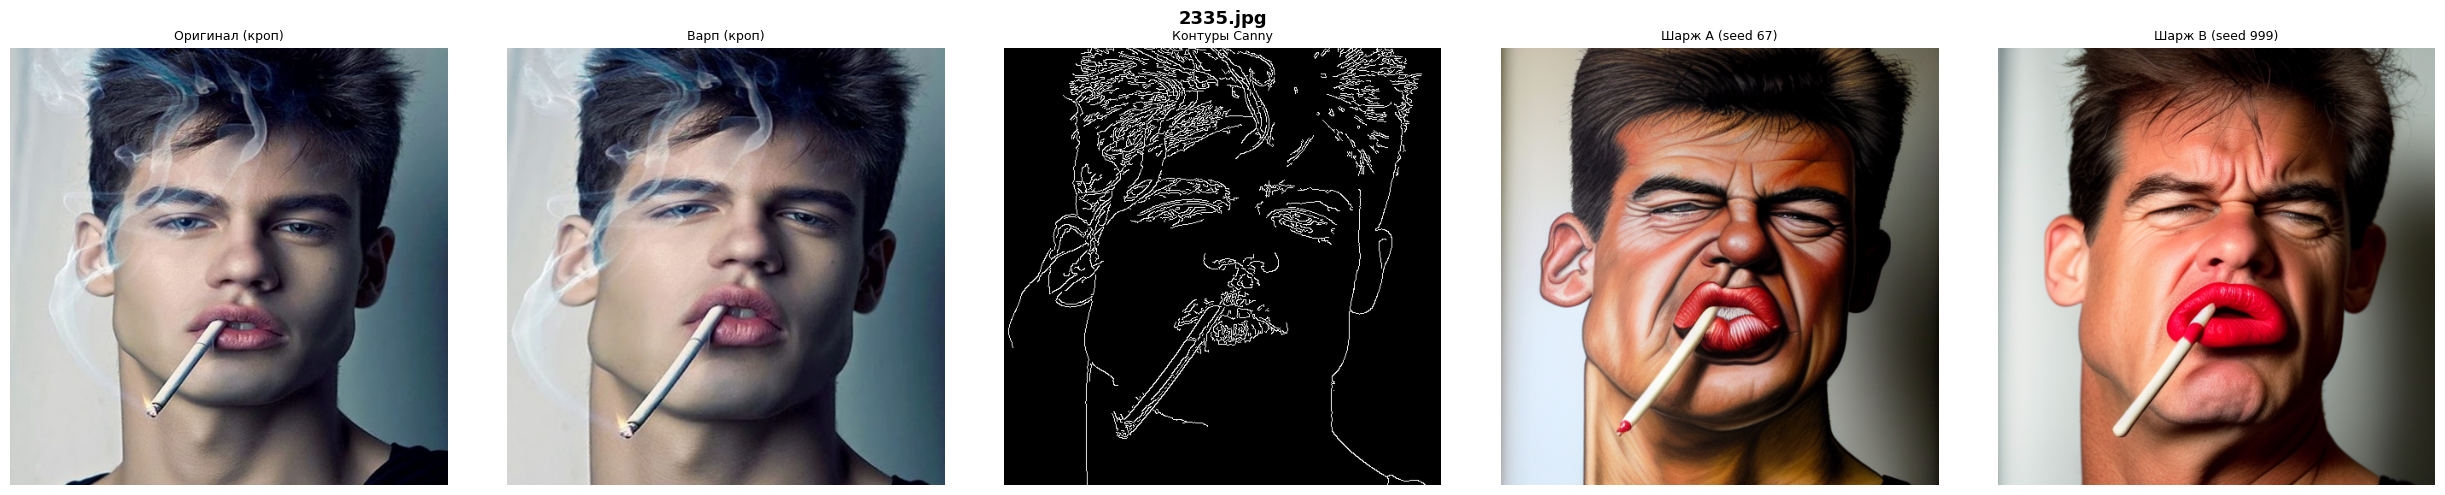


✅ Тест успешен


<Figure size 640x480 with 0 Axes>

In [19]:
# ── Выбор тестового изображения ───────────────────────────────────────────────
USE_RANDOM_IMAGE = False
SELECT_IMAGE     = "2335.jpg"
VALID_EXTS       = {".jpg", ".jpeg", ".png", ".webp"}

if USE_RANDOM_IMAGE:
    candidates = [p for p in DATASET_DIR.iterdir()
                  if p.is_file() and p.suffix.lower() in VALID_EXTS]
    assert candidates, f"В {DATASET_DIR} нет изображений"
    ORIGINAL_IMG_PATH = random.choice(candidates)
else:
    ORIGINAL_IMG_PATH = DATASET_DIR / SELECT_IMAGE
    assert ORIGINAL_IMG_PATH.exists(), f"Не найдено: {ORIGINAL_IMG_PATH}"

# ── Папка для сохранения теста ────────────────────────────────────────────────
TEST_DIR = NOTEBOOK_DIR / "test" / ORIGINAL_IMG_PATH.stem
TEST_DIR.mkdir(parents=True, exist_ok=True)
print(f"🖼  Тест: {ORIGINAL_IMG_PATH.name}")
print(f"📁 Сохранение: {TEST_DIR}")

# ── Варп ──────────────────────────────────────────────────────────────────────
warp_result = run_warp_module(
    image_path = ORIGINAL_IMG_PATH,
    aggregator = aggregator,
    groups     = groups,
    output_dir = OUTPUT_DIR,
    strength   = 2.1,
)
assert warp_result is not None, "Варп вернул None — проверьте изображение"
warped_pil, positive_prompt, negative_prompt = warp_result

print(f"  Промпт: {positive_prompt[:80]}...")

# ── InsightFace ────────────────────────────────────────────────────────────────
img_bgr = cv2.imread(str(ORIGINAL_IMG_PATH))
assert img_bgr is not None
faces = face_app.get(img_bgr)
assert faces, "InsightFace не нашёл лиц"
face = sorted(
    faces,
    key=lambda f: (f.bbox[2]-f.bbox[0])*(f.bbox[3]-f.bbox[1]),
    reverse=True,
)[0]

# ── Генерация ─────────────────────────────────────────────────────────────────
print("🚀 Генерация пары шаржей...")
result = generate_caricature_pair(
    original_bgr    = img_bgr,
    face            = face,
    warped_pil      = warped_pil,
    positive_prompt = positive_prompt,
    negative_prompt = negative_prompt,
    pipe            = pipe,
)

# ── Сохранение ────────────────────────────────────────────────────────────────
# Копируем оригинал
import shutil
shutil.copy2(str(ORIGINAL_IMG_PATH), str(TEST_DIR / "original.jpg"))

# Сохраняем все результаты пайплайна
save_map = {
    "original_crop" : "original_crop.png",
    "warped_crop"   : "warped_crop.png",
    "canny_mask"    : "canny_mask.png",
    "caricature_A"  : f"caricature_seed{SEED_A}.png",
    "caricature_B"  : f"caricature_seed{SEED_B}.png",
}
for key, filename in save_map.items():
    fpath = TEST_DIR / filename
    result[key].save(str(fpath))
    print(f"  💾 {filename}")

# Сохраняем промпты в текстовый файл
prompt_path = TEST_DIR / "prompts.txt"
with open(prompt_path, "w", encoding="utf-8") as f:
    f.write(f"positive_prompt:\n{positive_prompt}\n\n")
    f.write(f"negative_prompt:\n{negative_prompt}\n")
print(f"  💾 prompts.txt")

# Сохраняем метаданные
import json
meta = {
    "image"          : ORIGINAL_IMG_PATH.name,
    "strength"       : 2.1,
    "seed_A"         : SEED_A,
    "seed_B"         : SEED_B,
    "denoise"        : DENOISE_STRENGTH,
    "guidance"       : GUIDANCE_SCALE,
    "ip_adapter"     : IP_ADAPTER_SCALE,
    "controlnet_w"   : CONTROLNET_WEIGHT,
    "positive_prompt": positive_prompt,
    "negative_prompt": negative_prompt,
}
with open(TEST_DIR / "meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print(f"  💾 meta.json")

print(f"\n✅ Всё сохранено в: {TEST_DIR}")
print(f"   Структура:")
for p in sorted(TEST_DIR.iterdir()):
    print(f"   ├── {p.name}")

# ── Визуализация ──────────────────────────────────────────────────────────────
visualize_pipeline(result, title=ORIGINAL_IMG_PATH.name)

# Сохраняем итоговый дашборд
fig_path = TEST_DIR / "dashboard.png"
plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
print(f"\n✅ Тест успешен")

📁 Сохранение: /home/kseno/CaricatureGenerator/noteboks/test2/2335

Размер изображения: 682x1024
Landmarks извлечены: (478, 2)
Диапазон X: 157 – 550
Диапазон Y: 197 – 668

Вектор преувеличения (первые 10 точек):
[[ 0.00892304 -0.18409716]
 [ 0.16644571 -0.55027075]
 [ 0.08480876 -0.38315617]
 [ 0.06457568 -0.20148401]
 [ 0.19362675 -0.5462116 ]
 [ 0.18847564 -0.50465599]
 [ 0.13008607 -0.32040898]
 [-0.01564288 -0.02181572]
 [ 0.05838686 -0.07972419]
 [ 0.06574614 -0.06733914]]

Максимальное отклонение (нормализованное): 0.5503

Межзрачковое расстояние: 246.4 пикселей
Максимальный сдвиг в пикселях: 135.6
Средний сдвиг в пикселях: 17.0

  💾 diagnostic_dashboard.png


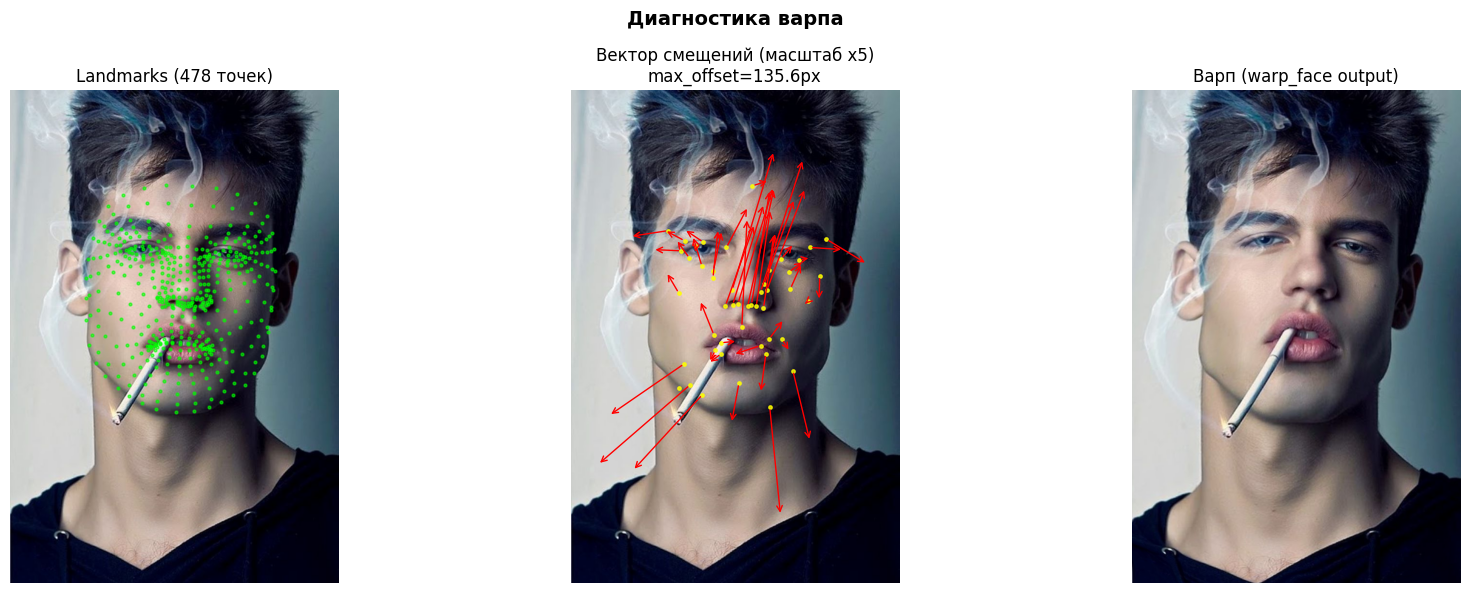

  💾 original.jpg
  💾 01_landmarks.png
  💾 02_offsets.png
  💾 03_warped.png
  💾 04_diff_map.png
  💾 diagnostic_data.json
  💾 exaggeration_vector.npy ((478, 2))

Форма warped_np: (1024, 682, 3)
Отличается от оригинала: True
Среднее абсолютное отличие: 20.19

✅ Всё сохранено в: /home/kseno/CaricatureGenerator/noteboks/test2/2335
   Структура:
   ├── 01_landmarks.png                    ( 626.1 KB)
   ├── 02_offsets.png                      ( 631.0 KB)
   ├── 03_warped.png                       ( 619.7 KB)
   ├── 04_diff_map.png                     ( 834.8 KB)
   ├── diagnostic_dashboard.png            (1038.9 KB)
   ├── diagnostic_data.json                (   0.4 KB)
   ├── exaggeration_vector.npy             (   7.6 KB)
   ├── original.jpg                        (  68.9 KB)


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
from pathlib import Path

# ── 0. Папка для сохранения ──────────────────────────────────────────────────
TEST2_DIR = NOTEBOOK_DIR / "test2" / ORIGINAL_IMG_PATH.stem
TEST2_DIR.mkdir(parents=True, exist_ok=True)
print(f"📁 Сохранение: {TEST2_DIR}\n")

# ── 1. Берём тестовое изображение ────────────────────────────────────────────
img_bgr = cv2.imread(str(ORIGINAL_IMG_PATH))
h, w    = img_bgr.shape[:2]
print(f"Размер изображения: {w}x{h}")

# ── 2. Извлекаем landmarks ────────────────────────────────────────────────────
landmarks = aggregator.extract_landmarks_from_image(str(ORIGINAL_IMG_PATH))
print(f"Landmarks извлечены: {landmarks.shape}")
print(f"Диапазон X: {landmarks[:,0].min()} – {landmarks[:,0].max()}")
print(f"Диапазон Y: {landmarks[:,1].min()} – {landmarks[:,1].max()}")

# ── 3. Смотрим на вектор преувеличения ───────────────────────────────────────
params      = get_caricature_parameters(
    aggregator, groups, str(ORIGINAL_IMG_PATH), strength=1.5
)
ex_vector   = params['exaggeration_vector']
print(f"\nВектор преувеличения (первые 10 точек):")
print(ex_vector[:10])
print(f"\nМаксимальное отклонение (нормализованное): {np.abs(ex_vector).max():.4f}")

# ── 4. Вычисляем pixel_offsets как это делает warp_face ──────────────────────
left_eye     = landmarks[33]
right_eye    = landmarks[263]
eye_distance = np.linalg.norm(left_eye - right_eye)
print(f"\nМежзрачковое расстояние: {eye_distance:.1f} пикселей")

pixel_offsets = ex_vector * eye_distance
print(f"Максимальный сдвиг в пикселях: {np.abs(pixel_offsets).max():.1f}")
print(f"Средний сдвиг в пикселях: {np.abs(pixel_offsets).mean():.1f}")

# ── 5. Визуализация (3 панели) ───────────────────────────────────────────────
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Панель 1: landmarks
axes[0].imshow(img_rgb)
axes[0].scatter(landmarks[:, 0], landmarks[:, 1], c='lime', s=4, alpha=0.6)
axes[0].set_title(f"Landmarks ({len(landmarks)} точек)")
axes[0].axis('off')

# Панель 2: стрелки смещений
axes[1].imshow(img_rgb)
step  = 10
scale = 5
for i in range(0, len(landmarks), step):
    x, y   = landmarks[i]
    dx, dy = pixel_offsets[i] * scale
    if abs(dx) > 0.5 or abs(dy) > 0.5:
        axes[1].annotate(
            "", xy=(x + dx, y + dy), xytext=(x, y),
            arrowprops=dict(arrowstyle="->", color="red", lw=1.0)
        )
axes[1].scatter(landmarks[::step, 0], landmarks[::step, 1],
                c='yellow', s=6, alpha=0.8)
axes[1].set_title(f"Вектор смещений (масштаб x{scale})\n"
                  f"max_offset={np.abs(pixel_offsets).max():.1f}px")
axes[1].axis('off')

# Панель 3: результат варпа
warped_np = aggregator.warp_face(
    str(ORIGINAL_IMG_PATH),
    caricature_params=params,
    target_size=(h, w),
)
axes[2].imshow(warped_np)
axes[2].set_title("Варп (warp_face output)")
axes[2].axis('off')

plt.suptitle("Диагностика варпа", fontsize=14, fontweight='bold')
plt.tight_layout()

# ── 6. Сохранение визуализаций ───────────────────────────────────────────────
# Сохраняем общий дашборд ДО show()
dashboard_path = TEST2_DIR / "diagnostic_dashboard.png"
fig.savefig(str(dashboard_path), dpi=150, bbox_inches='tight')
print(f"\n  💾 {dashboard_path.name}")

plt.show()
plt.close(fig)

# ── 7. Сохраняем отдельные картинки ──────────────────────────────────────────
# Копия оригинала
import shutil
shutil.copy2(str(ORIGINAL_IMG_PATH), str(TEST2_DIR / f"original{ORIGINAL_IMG_PATH.suffix}"))
print(f"  💾 original{ORIGINAL_IMG_PATH.suffix}")

# Оригинал с landmarks (отдельно)
fig_lm, ax_lm = plt.subplots(figsize=(8, 8))
ax_lm.imshow(img_rgb)
ax_lm.scatter(landmarks[:, 0], landmarks[:, 1], c='lime', s=4, alpha=0.6)
ax_lm.set_title(f"Landmarks ({len(landmarks)} точек)")
ax_lm.axis('off')
fig_lm.savefig(str(TEST2_DIR / "01_landmarks.png"), dpi=150, bbox_inches='tight')
plt.close(fig_lm)
print(f"  💾 01_landmarks.png")

# Оригинал со стрелками смещений (отдельно)
fig_arr, ax_arr = plt.subplots(figsize=(8, 8))
ax_arr.imshow(img_rgb)
for i in range(0, len(landmarks), step):
    x, y   = landmarks[i]
    dx, dy = pixel_offsets[i] * scale
    if abs(dx) > 0.5 or abs(dy) > 0.5:
        ax_arr.annotate(
            "", xy=(x + dx, y + dy), xytext=(x, y),
            arrowprops=dict(arrowstyle="->", color="red", lw=1.0)
        )
ax_arr.scatter(landmarks[::step, 0], landmarks[::step, 1],
               c='yellow', s=6, alpha=0.8)
ax_arr.set_title(f"Вектор смещений (масштаб x{scale})\n"
                 f"max_offset={np.abs(pixel_offsets).max():.1f}px")
ax_arr.axis('off')
fig_arr.savefig(str(TEST2_DIR / "02_offsets.png"), dpi=150, bbox_inches='tight')
plt.close(fig_arr)
print(f"  💾 02_offsets.png")

# Варп как чистая картинка (без matplotlib)
warped_pil = Image.fromarray(warped_np)
warped_pil.save(str(TEST2_DIR / "03_warped.png"))
print(f"  💾 03_warped.png")

# ── 8. Карта разницы оригинал vs варп ────────────────────────────────────────
diff_map = np.abs(img_rgb.astype(float) - warped_np.astype(float))
diff_vis = (diff_map / max(diff_map.max(), 1) * 255).astype(np.uint8)
Image.fromarray(diff_vis).save(str(TEST2_DIR / "04_diff_map.png"))
print(f"  💾 04_diff_map.png")

# ── 9. Сохраняем числовые данные ─────────────────────────────────────────────
import json
diag_data = {
    "image":               ORIGINAL_IMG_PATH.name,
    "image_size_wh":       [int(w), int(h)],
    "n_landmarks":         int(len(landmarks)),
    "landmarks_range_x":   [int(landmarks[:,0].min()), int(landmarks[:,0].max())],
    "landmarks_range_y":   [int(landmarks[:,1].min()), int(landmarks[:,1].max())],
    "eye_distance_px":     float(eye_distance),
    "max_exaggeration":    float(np.abs(ex_vector).max()),
    "max_offset_px":       float(np.abs(pixel_offsets).max()),
    "mean_offset_px":      float(np.abs(pixel_offsets).mean()),
    "warp_pixel_diff":     float(diff_map.mean()),
    "strength":            1.5,
}
with open(TEST2_DIR / "diagnostic_data.json", "w", encoding="utf-8") as f:
    json.dump(diag_data, f, ensure_ascii=False, indent=2)
print(f"  💾 diagnostic_data.json")

# Сохраняем сам вектор преувеличения (numpy)
np.save(str(TEST2_DIR / "exaggeration_vector.npy"), ex_vector)
print(f"  💾 exaggeration_vector.npy ({ex_vector.shape})")

# ── 10. Итоги ────────────────────────────────────────────────────────────────
print(f"\nФорма warped_np: {warped_np.shape}")
print(f"Отличается от оригинала: {not np.array_equal(img_rgb, warped_np)}")
print(f"Среднее абсолютное отличие: {diff_map.mean():.2f}")

print(f"\n✅ Всё сохранено в: {TEST2_DIR}")
print(f"   Структура:")
for p in sorted(TEST2_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"   ├── {p.name:<35} ({size_kb:>6.1f} KB)")

In [21]:
import subprocess, sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "qwen-vl-utils",
    "transformers>=4.45.0",   # Qwen2-VL требует свежую версию
])

print("✅ qwen-vl-utils установлен")

✅ qwen-vl-utils установлен


In [22]:
import re

JUDGE_MODEL_ID = "Qwen/Qwen2-VL-7B-Instruct"


# ── New prompt: forces reasoning before verdict ────────────────────────────────
JUDGE_PROMPT_WITH_REASONING = """You are an expert caricature critic.

You will see three images:
- IMAGE 1: Original photograph (reference face)
- IMAGE 2: Caricature variant A
- IMAGE 3: Caricature variant B

Step 1 — Describe caricature A: what features are exaggerated, is it funny, does the person look recognizable?
Step 2 — Describe caricature B: same questions.
Step 3 — Compare: which one has better humor + recognizability + artistic quality?
Step 4 — State your final verdict.

You MUST end your response with exactly one of these two lines:
VERDICT: A
VERDICT: B"""


def load_judge():
    from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
    gc.collect()
    torch.cuda.empty_cache()

    print(f"  Загрузка судьи {JUDGE_MODEL_ID} → строго на cuda:3...")

    processor = AutoProcessor.from_pretrained(
        JUDGE_MODEL_ID,
        min_pixels=256 * 28 * 28,
        max_pixels=512 * 28 * 28,
    )

    # ── ИСПРАВЛЕНИЕ: device_map="auto" заменяем на явный GPU ─────────
    # "auto" может захватить cuda:0 если cuda:3 не хватает места
    # Явно указываем cuda:3 через max_memory
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        JUDGE_MODEL_ID,
        torch_dtype=torch.float16,
        device_map={
            "": "cuda:3"    # все слои строго на cuda:3
        },
    )
    model.eval()
    print("✅ Судья загружен на cuda:3")
    return model, processor


def unload_judge(model, processor) -> None:
    """Полная выгрузка судьи с очисткой памяти cuda:3."""
    model.to("cpu")          # сначала на CPU
    del model, processor
    gc.collect()

    # Очищаем все GPU
    for i in range(torch.cuda.device_count()):
        torch.cuda.empty_cache()
        torch.cuda.synchronize(i)

    print("✅ Судья выгружен")
    for i in range(torch.cuda.device_count()):
        free = get_free_vram_gb(i)
        print(f"   GPU {i}: {free:.2f} ГБ свободно")


def _run_judge_once(
    model,
    processor,
    original_crop: Image.Image,
    img_left: Image.Image,
    img_right: Image.Image,
    label_left: str = "A",
    label_right: str = "B",
) -> str:
    """Один вызов судьи. Возвращает победителя в терминах оригинальных меток A/B."""
    from qwen_vl_utils import process_vision_info

    messages = [{
        "role": "user",
        "content": [
            {"type": "text",  "text": "IMAGE 1 (Original):"},
            {"type": "image", "image": original_crop},
            {"type": "text",  "text": f"IMAGE 2 (Caricature {label_left}):"},
            {"type": "image", "image": img_left},
            {"type": "text",  "text": f"IMAGE 3 (Caricature {label_right}):"},
            {"type": "image", "image": img_right},
            {"type": "text",  "text": JUDGE_PROMPT_WITH_REASONING},
        ],
    }]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        return_tensors="pt",
        padding=True,
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=350,
            do_sample=False,
            temperature=None,
            top_p=None,
        )

    generated = output_ids[0][inputs["input_ids"].shape[1]:]
    full_response = processor.decode(generated, skip_special_tokens=True).strip()

    # Ищем "VERDICT: A" или "VERDICT: B"
    match = re.search(r'VERDICT:\s*([AB])', full_response, re.IGNORECASE)
    if match:
        verdict_in_call = match.group(1).upper()
    else:
        # Запасной вариант: последнее одиночное A или B в тексте
        words = re.findall(r'\b([AB])\b', full_response.upper())
        verdict_in_call = words[-1] if words else "A"
        print(f"  [judge] нет тега VERDICT, fallback: '{verdict_in_call}'")

    # Переводим обратно в оригинальные метки
    return label_left if verdict_in_call == "A" else label_right


def judge_pair(
    model,
    processor,
    original_crop: Image.Image,
    caricature_A: Image.Image,
    caricature_B: Image.Image,
) -> Optional[str]:
    """
    Симметричный судья: запускает оценку дважды с перестановкой A/B.
    Возвращает 'A', 'B' или None — если оба запуска не согласны (позиционный bias → пропустить пару).
    """
    # Запуск 1: A слева, B справа
    result_1 = _run_judge_once(
        model, processor, original_crop,
        caricature_A, caricature_B,
        label_left="A", label_right="B"
    )

    # Запуск 2: B слева, A справа
    result_2 = _run_judge_once(
        model, processor, original_crop,
        caricature_B, caricature_A,
        label_left="B", label_right="A"
    )

    if result_1 == result_2:
        print(f"  [symmetric ✓] оба запуска согласны: {result_1}")
        return result_1
    else:
        print(f"  [symmetric ✗] расходятся ({result_1} vs {result_2}) — пропускаем")
        return None


print("✅ Судья определён")

✅ Судья определён


In [23]:
import time

def get_free_vram_gb(device_idx: int = 0) -> float:
    free, _ = torch.cuda.mem_get_info(device_idx)
    return free / (1024 ** 3)


def offload_pipe(pipe) -> None:
    for name in ["unet", "vae", "text_encoder", "controlnet"]:
        comp = getattr(pipe, name, None)
        if comp is not None and hasattr(comp, "to"):
            comp.to("cpu")
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize(0)
    free = get_free_vram_gb(0)
    print(f"✅ SD pipeline выгружен | Свободно cuda:0: {free:.2f} ГБ")


def restore_pipe(
    pipe,
    device      : str = "cuda:0",
    max_retries : int = 10,
    wait_sec    : int = 30,
) -> bool:
    """
    Возвращает pipe на GPU компонент за компонентом.
    При OOM — откатывает уже загруженное обратно на CPU,
    ждёт wait_sec секунд и повторяет.
    """
    device_idx = int(device.split(":")[-1]) if ":" in device else 0
    components = ["unet", "vae", "text_encoder", "controlnet"]

    for attempt in range(1, max_retries + 1):
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize(device_idx)

        free_gb = get_free_vram_gb(device_idx)
        print(f"\n  🔄 restore_pipe: попытка {attempt}/{max_retries} "
              f"| Свободно {device}: {free_gb:.2f} ГБ")

        # Ждём если памяти меньше 2 ГБ — даже не пробуем
        if free_gb < 2.0:
            print(f"  ⏳ Памяти < 2 ГБ. "
                  f"Ждём {wait_sec} сек пока другие процессы освободят GPU...")
            time.sleep(wait_sec)
            continue

        # Пробуем загружать компонент за компонентом
        loaded = []
        success = True

        for name in components:
            comp = getattr(pipe, name, None)
            if comp is None or not hasattr(comp, "to"):
                continue
            try:
                comp.to(device)
                loaded.append(name)
            except (RuntimeError, torch.cuda.OutOfMemoryError) as e:
                if "out of memory" in str(e).lower():
                    print(f"  ⚠️  OOM при загрузке '{name}' "
                          f"(загружено: {loaded})")
                    success = False
                    break
                else:
                    raise

        if success:
            gc.collect()
            torch.cuda.empty_cache()
            free_after = get_free_vram_gb(device_idx)
            print(f"✅ pipe восстановлен на {device} "
                  f"| Осталось: {free_after:.2f} ГБ")
            return True

        # Откатываем уже загруженные компоненты обратно на CPU
        print(f"  🔙 Откат: возвращаем {loaded} на CPU...")
        for name in loaded:
            comp = getattr(pipe, name, None)
            if comp is not None:
                try:
                    comp.to("cpu")
                except Exception:
                    pass

        gc.collect()
        torch.cuda.empty_cache()
        print(f"  ⏳ Ждём {wait_sec} сек...")
        time.sleep(wait_sec)

    print(f"❌ restore_pipe: не удалось после {max_retries} попыток")
    return False

print("✅ offload_pipe / restore_pipe переопределены")

✅ offload_pipe / restore_pipe переопределены


In [24]:
def find_warp_output(base_dir: Path, image_stem: str) -> Path | None:
    """
    Ищет JSON-конфиг для конкретного изображения.
    Когда коллега отдаст модуль — используйте эту функцию
    вместо warp_stub в run_dataset_generation.

    Варианты структуры папок:
      base_dir/{stem}/config.json   ← вариант А
      base_dir/{stem}.json          ← вариант Б
      base_dir/config.json          ← вариант В
    """
    candidates = [
        base_dir / image_stem / "config.json",
        base_dir / f"{image_stem}.json",
        base_dir / "config.json",
    ]
    for c in candidates:
        if c.exists():
            return c
    return None


print("✅ find_warp_output определена")

✅ find_warp_output определена


In [25]:
def save_pair(
    result         : dict,
    image_stem     : str,
    output_dir     : Path,
    positive_prompt: str = "",
    negative_prompt: str = "",
) -> dict:
    pair_dir = output_dir / image_stem
    pair_dir.mkdir(parents=True, exist_ok=True)

    saved = {}
    for key, img in result.items():
        fpath = pair_dir / f"{key}.png"
        img.save(str(fpath))
        saved[key] = str(fpath.relative_to(output_dir))

    # Судья ещё не запускался — правильный статус "pending"
    # chosen/rejected будут переставлены в run_judge_phase
    return {
        "id"            : image_stem,
        "chosen"        : saved["caricature_A"],   # временно A
        "rejected"      : saved["caricature_B"],   # временно B
        "original_crop" : saved["original_crop"],
        "warped_crop"   : saved["warped_crop"],
        "canny_mask"    : saved["canny_mask"],
        "judge"         : "pending",              
        "prompt"        : positive_prompt or FALLBACK_PROMPT,
        "negative_prompt": negative_prompt,
    }

print("✅ save_pair определена")

✅ save_pair определена


In [26]:
def run_dataset_generation(
    dataset_dir       : Path,
    output_dir        : Path,
    pipe,
    aggregator        : "MediaPipeFaceAggregator",
    groups            : dict,
    extensions        : tuple[str, ...] = (".jpg", ".jpeg", ".png", ".webp"),
    max_images        : int | None = None,
    shuffle_remaining : bool = False,
    warp_strength     : float = 2,
) -> int:
    """
    Генерирует пары шаржей используя реальный модуль деформации.

    Изменения vs старой версии:
    - убран параметр warp_base_dir (JSON больше не нужен)
    - добавлены aggregator, groups, warp_strength
    - вместо warp_stub вызывается run_warp_module
    """
    all_image_paths = sorted([
        p for p in dataset_dir.iterdir()
        if p.suffix.lower() in extensions
    ])

    manifest_path = output_dir / "manifest.json"
    manifest: list[dict] = []
    done_ids: set[str] = set()

    if manifest_path.exists():
        with open(manifest_path, encoding="utf-8") as f:
            manifest = json.load(f)
        done_ids = {m["id"] for m in manifest}
        print(f"  Продолжаем: {len(done_ids)} пар уже готово")

    remaining = [p for p in all_image_paths if p.stem not in done_ids]

    if shuffle_remaining:
        random.shuffle(remaining)
    if max_images is not None:
        remaining = remaining[:max_images]

    total     = len(remaining)
    generated = 0

    if total == 0:
        print("  Необработанных изображений не осталось")
        return 0

    for idx, img_path in enumerate(remaining):
        stem = img_path.stem
        tag  = f"[{idx+1}/{total}]"
        print(f"{tag} {img_path.name} ...", end="  ")

        # ── Варп через модуль коллеги ─────────────────────────────────
        warp_result = run_warp_module(
            image_path = img_path,
            aggregator = aggregator,
            groups     = groups,
            output_dir = output_dir,
            strength   = warp_strength,
        )
        if warp_result is None:
            print("⚠️  Варп не удался — пропускаем")
            continue

        warped_pil, positive_prompt, negative_prompt = warp_result

        # ── Детекция лица InsightFace ─────────────────────────────────
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            print("❌ imread вернул None — пропускаем")
            continue

        faces = face_app.get(img_bgr)
        if not faces:
            print("⚠️  InsightFace не нашёл лица — пропускаем")
            continue

        face = sorted(
            faces,
            key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]),
            reverse=True,
        )[0]

        # ── Генерация пары шаржей ─────────────────────────────────────
        try:
            result = generate_caricature_pair(
                original_bgr    = img_bgr,
                face            = face,
                warped_pil      = warped_pil,
                positive_prompt = positive_prompt,
                negative_prompt = negative_prompt,
                pipe            = pipe,
            )
        except Exception as exc:
            print(f"❌ Генерация: {exc}")
            gc.collect()
            torch.cuda.empty_cache()
            continue

        # ── Сохранение ────────────────────────────────────────────────
        meta = save_pair(
            result          = result,
            image_stem      = stem,
            output_dir      = output_dir,
            positive_prompt = positive_prompt,
            negative_prompt = negative_prompt,
        )
        manifest.append(meta)
        done_ids.add(stem)
        generated += 1

        with open(manifest_path, "w", encoding="utf-8") as f:
            json.dump(manifest, f, ensure_ascii=False, indent=2)

        print(f"✅  -> {output_dir / stem}/")

        del result, img_bgr, faces, face, warped_pil
        gc.collect()
        torch.cuda.empty_cache()

    print(f"\n  Сгенерировано новых пар: {generated} (всего: {len(manifest)})")
    return generated


print("✅ run_dataset_generation обновлена")

✅ run_dataset_generation обновлена


In [27]:
def run_judge_phase(output_dir: Path, model, processor) -> int:
    manifest_path = output_dir / "manifest.json"
    with open(manifest_path, encoding="utf-8") as f:
        manifest = json.load(f)

    pending = [m for m in manifest if m.get("judge") == "pending"]
    print(f"  Пар на оценку: {len(pending)}")
    if not pending:
        return 0

    evaluated, skipped_bias = 0, 0

    for meta in pending:
        pair_id = meta["id"]
        print(f"  {pair_id} ...", end=" ")
        try:
            original = Image.open(output_dir / meta["original_crop"]).convert("RGB")
            img_a    = Image.open(output_dir / meta["chosen"]).convert("RGB")
            img_b    = Image.open(output_dir / meta["rejected"]).convert("RGB")
        except Exception as e:
            print(f"❌ Загрузка: {e}")
            continue

        winner = judge_pair(model, processor, original, img_a, img_b)

        if winner is None:
            # Два запуска не согласились — позиционный bias, не используем эту пару
            meta["judge"] = "skipped_bias"
            skipped_bias += 1
        elif winner == "A":
            meta["chosen"]   = f"{pair_id}/caricature_A.png"
            meta["rejected"] = f"{pair_id}/caricature_B.png"
            meta["judge"] = "Qwen2-VL+symmetric -> A"
            evaluated += 1
        else:
            meta["chosen"]   = f"{pair_id}/caricature_B.png"
            meta["rejected"] = f"{pair_id}/caricature_A.png"
            meta["judge"] = "Qwen2-VL+symmetric -> B"
            evaluated += 1

        with open(manifest_path, "w", encoding="utf-8") as f:
            json.dump(manifest, f, ensure_ascii=False, indent=2)

        print(f"✅ -> {winner or 'skip'}")

    print(f"\n  Оценено: {evaluated} пар, пропущено (bias): {skipped_bias}")
    return evaluated

print("✅ run_judge_phase определена")

✅ run_judge_phase определена


In [28]:
import subprocess, sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "trl>=0.8.0",
    "peft>=0.10.0",
    "accelerate>=0.27.0",
    "datasets>=2.18.0",
])

print("✅ DPO зависимости установлены")

✅ DPO зависимости установлены


In [29]:
def offload_pipe(pipe) -> None:
    """
    Выгружает SD pipeline из VRAM покомпонентно.
    Избегаем pipe.to('cpu') который ломается на fp16.
    """
    for name in ["unet", "vae", "text_encoder", "controlnet"]:
        component = getattr(pipe, name, None)
        if component is not None and hasattr(component, "to"):
            component.to("cpu")

    gc.collect()
    torch.cuda.empty_cache()
    print("✅ SD pipeline выгружен из VRAM")


def restore_pipe(pipe) -> None:
    """Возвращает компоненты SD pipeline на GPU."""
    for name in ["unet", "vae", "text_encoder", "controlnet"]:
        component = getattr(pipe, name, None)
        if component is not None and hasattr(component, "to"):
            component.to("cuda")

    gc.collect()
    torch.cuda.empty_cache()
    print("✅ SD pipeline возвращён на GPU")


print("✅ offload_pipe / restore_pipe определены")

✅ offload_pipe / restore_pipe определены


In [30]:
# %%
# Фиксированное назначение GPU под каждую задачу

# GPU 0: generation (SD + ControlNet + IP-Adapter) — уже там
# GPU 1: reference UNet (заморожен)
# GPU 2: policy UNet (обучаемый LoRA)
# GPU 3: Qwen2-VL judge

DEVICE_GENERATION = "cuda:1"
DEVICE_REFERENCE  = "cuda:1"
DEVICE_POLICY     = "cuda:2"
DEVICE_JUDGE      = "cuda:3"   # device_map="auto" у Qwen сам займёт GPU 3

print(f"  Generation : {DEVICE_GENERATION}")
print(f"  Reference  : {DEVICE_REFERENCE}")
print(f"  Policy     : {DEVICE_POLICY}")
print(f"  Judge      : {DEVICE_JUDGE}")
print("✅ GPU назначения определены")

  Generation : cuda:1
  Reference  : cuda:1
  Policy     : cuda:2
  Judge      : cuda:3
✅ GPU назначения определены


In [31]:
import copy
import base64
import io
import shutil
import numpy as np
import torch
import torch.nn.functional as F
from datasets import Dataset
from peft import LoraConfig, get_peft_model, PeftModel
from diffusers import DDPMScheduler

TRAINING_LOG: list[dict] = []

DPO_CONFIG = {
    "lora_rank"     : 16,
    "lora_alpha"    : 32,
    "lora_dropout"  : 0.05,
    "learning_rate" : 1e-4,
    "beta"          : 0.1,
    "grad_accum"    : 4,
    "num_epochs"    : 3,
    "max_grad_norm" : 1.0,
    "save_dir"      : "dpo_checkpoints",
}


def pil_to_base64(img: Image.Image) -> str:
    buffer = io.BytesIO()
    img.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

def base64_to_pil(b64: str) -> Image.Image:
    return Image.open(io.BytesIO(base64.b64decode(b64))).convert("RGB")


def build_dpo_dataset(output_dir: Path, min_pairs: int = 10) -> Optional[Dataset]:
    manifest_path = output_dir / "manifest.json"
    if not manifest_path.exists():
        print("  manifest.json не найден")
        return None

    with open(manifest_path, encoding="utf-8") as f:
        manifest = json.load(f)

    evaluated = [m for m in manifest if m.get("judge") not in ("pending", None, "skipped_bias")]
    if len(evaluated) < min_pairs:
        print(f"  Оценённых пар: {len(evaluated)}, нужно минимум {min_pairs}")
        return None

    print(f"  Строим DPO датасет из {len(evaluated)} пар...")
    records, skipped = [], 0

    for meta in evaluated:
        try:
            chosen_img   = Image.open(output_dir / meta["chosen"]).convert("RGB")
            rejected_img = Image.open(output_dir / meta["rejected"]).convert("RGB")
            original_img = Image.open(output_dir / meta["original_crop"]).convert("RGB")

            prompt = meta.get("prompt")
            if not isinstance(prompt, str) or not prompt.strip():
                prompt = FALLBACK_PROMPT

            records.append({
                "prompt"  : prompt,
                "chosen"  : pil_to_base64(chosen_img),
                "rejected": pil_to_base64(rejected_img),
                "original": pil_to_base64(original_img),
                "id"      : meta["id"],
                "judge"   : meta.get("judge", "unknown"),
            })
        except Exception as e:
            print(f"  Пропуск {meta.get('id','?')}: {e}")
            skipped += 1

    print(f"  Готово: {len(records)} пар, пропущено: {skipped}")
    return Dataset.from_list(records) if records else None


def precompute_latent_cache(
    dpo_dataset: Dataset,
    pipe,
    device: str = DEVICE_GENERATION,
) -> list[dict]:
    print(f"  Предвычисляем латенты ({len(dpo_dataset)} пар)...")
    pipe.vae.to(device)
    pipe.text_encoder.to(device)

    def img_to_latent(img_pil: Image.Image) -> torch.Tensor:
        img_np = np.array(img_pil.resize((CROP_SIZE, CROP_SIZE))).astype(np.float32)
        t = (
            torch.from_numpy(img_np / 127.5 - 1.0)
            .permute(2, 0, 1)
            .unsqueeze(0)
            .to(dtype=torch.float16, device=device)
        )
        with torch.no_grad():
            lat = pipe.vae.encode(t).latent_dist.sample()
            lat = lat * pipe.vae.config.scaling_factor
        return lat.to("cpu")

    def text_to_embeds(prompt_str: str) -> torch.Tensor:
        tokens = pipe.tokenizer(
            prompt_str,
            padding="max_length",
            max_length=pipe.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        ).input_ids.to(device)
        with torch.no_grad():
            emb = pipe.text_encoder(tokens)[0]
        return emb.to("cpu")

    # ── ИСПРАВЛЕНО: функции вынесены из цикла ────────────────────────
    # В оригинале def внутри for — переопределялись на каждой итерации
    cache = []
    for i, sample in enumerate(dpo_dataset):
        try:
            sample       = dict(sample)
            prompt       = sample.get("prompt") or FALLBACK_PROMPT
            chosen_img   = base64_to_pil(sample["chosen"])
            rejected_img = base64_to_pil(sample["rejected"])

            cache.append({
                "chosen_latent" : img_to_latent(chosen_img),
                "rejected_latent": img_to_latent(rejected_img),
                "prompt_embeds" : text_to_embeds(prompt),
                "id"            : sample.get("id", str(i)),
            })
            if (i + 1) % 10 == 0 or i == 0:
                print(f"  [{i+1}/{len(dpo_dataset)}] готово")
        except Exception as e:
            print(f"  Пропуск {i}: {e}")

    pipe.vae.to("cpu")
    pipe.text_encoder.to("cpu")
    gc.collect(); torch.cuda.empty_cache()

    print(f"  Кеш готов: {len(cache)} пар на CPU")
    return cache


# ──────────────────────────────────────────────────────────────────────
# Клонирование UNet через CPU
# ──────────────────────────────────────────────────────────────────────

def get_clean_unet_on_cpu(pipe) -> torch.nn.Module:
    """
    Создаёт чистую CPU-копию UNet без PEFT/IP-Adapter обёрток.
    Всё копирование происходит на CPU — не занимает VRAM.
    """
    # Переводим на CPU перед копированием
    pipe.unet.to("cpu")
    gc.collect()
    torch.cuda.empty_cache()

    unet = pipe.unet

    # Снимаем PEFT если есть
    if isinstance(unet, PeftModel):
        print("  Снимаем PEFT перед клонированием...")
        unet = unet.merge_and_unload()
        pipe.unet = unet

    # Копируем на CPU
    unet_copy = copy.deepcopy(unet)

    # Возвращаем оригинал на GPU 0
    pipe.unet.to(DEVICE_GENERATION)

    print("  Чистая CPU-копия UNet готова")
    return unet_copy  # на CPU


# ──────────────────────────────────────────────────────────────────────
# Сохранение чекпоинта
# ──────────────────────────────────────────────────────────────────────

def save_checkpoint(unet, cycle: int, save_dir: str) -> None:
    save_path = Path(save_dir) / f"cycle_{cycle:03d}"
    save_path.mkdir(parents=True, exist_ok=True)

    unet.save_pretrained(str(save_path))

    with open(save_path / "meta.json", "w", encoding="utf-8") as f:
        json.dump({
            "cycle"         : cycle,
            "lora_rank"     : DPO_CONFIG["lora_rank"],
            "learning_rate" : DPO_CONFIG["learning_rate"],
            "beta"          : DPO_CONFIG["beta"],
        }, f, indent=2)

    print(f"  Чекпоинт сохранён: {save_path}")

    all_ckpts = sorted(Path(save_dir).glob("cycle_*"))
    if len(all_ckpts) > 2:
        for old in all_ckpts[:-2]:
            shutil.rmtree(old)
            print(f"  Удалён старый чекпоинт: {old.name}")

In [32]:
def preview_recent_caricatures(
    output_dir  : Path,
    n           : int = 4,
    cycle       : int = 0,
    shown_ids   : set | None = None,
) -> set:
    """
    Показывает n последних оценённых пар которые ещё не были показаны.

    Параметры
    ----------
    shown_ids : множество id которые уже были показаны в предыдущих циклах.
                Передавайте между вызовами чтобы не повторяться.

    Возвращает обновлённое множество shown_ids.
    """
    if shown_ids is None:
        shown_ids = set()

    manifest_path = output_dir / "manifest.json"
    if not manifest_path.exists():
        print("  Манифест пуст — нечего показывать")
        return shown_ids

    with open(manifest_path, encoding="utf-8") as f:
        manifest = json.load(f)

    evaluated = [
        m for m in manifest
        if m.get("judge") not in ("pending", None)
    ]

    # Только новые — которых ещё не показывали
    new_pairs = [m for m in evaluated if m["id"] not in shown_ids]

    if not new_pairs:
        print("  Нет новых оценённых пар для показа")
        return shown_ids

    to_show = new_pairs[-n:]

    print(f"\n{'='*60}")
    print(f"  PREVIEW — Цикл {cycle} | Новых пар: {len(to_show)}")
    print(f"{'='*60}\n")

    for meta in to_show:
        try:
            chosen   = Image.open(output_dir / meta["chosen"]).convert("RGB")
            rejected = Image.open(output_dir / meta["rejected"]).convert("RGB")
            original = Image.open(output_dir / meta["original_crop"]).convert("RGB")

            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            fig.suptitle(
                f"ID: {meta['id']}  |  {meta.get('judge', '?')}",
                fontsize=11,
            )
            axes[0].imshow(original);  axes[0].set_title("Original");  axes[0].axis("off")
            axes[1].imshow(chosen);    axes[1].set_title("[Chosen]");   axes[1].axis("off")
            axes[2].imshow(rejected);  axes[2].set_title("[Rejected]"); axes[2].axis("off")
            plt.tight_layout()
            plt.show()

            shown_ids.add(meta["id"])

        except Exception as e:
            print(f"  Не удалось показать {meta['id']}: {e}")

    return shown_ids


print("✅ preview_recent_caricatures определена")

✅ preview_recent_caricatures определена


In [33]:
def run_dpo_training(
    dpo_dataset: Dataset,
    pipe,
    cycle      : int,
    save_dir   : str = DPO_CONFIG["save_dir"],
) -> Optional[dict]:
    if dpo_dataset is None or len(dpo_dataset) == 0:
        print("  DPO пропущен: датасет пуст")
        return None

    print(f"\n  DPO Fine-tuning (цикл {cycle}), пар: {len(dpo_dataset)}")

    # Состояние памяти
    for i in range(torch.cuda.device_count()):
        free = torch.cuda.mem_get_info(i)[0] / 1024**3
        print(f"  GPU {i}: {free:.1f} GB свободно")

    noise_scheduler = DDPMScheduler.from_config(pipe.scheduler.config)

    # 1. Латенты
    latent_cache = precompute_latent_cache(dpo_dataset, pipe, DEVICE_GENERATION)
    if not latent_cache:
        print("  Кеш пуст — DPO пропущен")
        return None

    # 2. Клонирование UNet
    unet_cpu = get_clean_unet_on_cpu(pipe)

    # 3. Reference → GPU 1
    reference_unet = copy.deepcopy(unet_cpu).to(DEVICE_REFERENCE)
    reference_unet.requires_grad_(False)
    reference_unet.eval()

    # 4. Policy + LoRA → GPU 2
    if isinstance(unet_cpu, PeftModel):
        unet_cpu = unet_cpu.merge_and_unload()
    policy_base = unet_cpu.to(DEVICE_POLICY)

    lora_config = LoraConfig(
        r              = DPO_CONFIG["lora_rank"],
        lora_alpha     = DPO_CONFIG["lora_alpha"],
        lora_dropout   = DPO_CONFIG["lora_dropout"],
        target_modules = ["to_q", "to_k", "to_v", "to_out.0"],
        bias           = "none",
    )
    policy_unet = get_peft_model(policy_base, lora_config)

    for name, param in policy_unet.named_parameters():
        if param.requires_grad:
            param.data = param.data.to(torch.float32)
        
    policy_unet.print_trainable_parameters()
    policy_unet.train()

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, policy_unet.parameters()),
        lr=DPO_CONFIG["learning_rate"],
        weight_decay=1e-4,
    )

    # ── Нулевой image_embeds для IP-Adapter во время DPO ─────────────
    def make_dummy_kwargs(device):
        return {"image_embeds": [
            torch.zeros((1, 1, 512), device=device, dtype=torch.float16)
        ]}

    from torch.cuda.amp import GradScaler
    scaler = GradScaler(init_scale=2**15)

    all_metrics, accum_count = [], 0
    optimizer.zero_grad()

    
    # 5. Training loop
    for epoch in range(DPO_CONFIG["num_epochs"]):
        print(f"\n  Эпоха {epoch+1}/{DPO_CONFIG['num_epochs']}")
        for step, idx in enumerate(torch.randperm(len(latent_cache)).tolist()):
            try:
                item = latent_cache[idx]
                chosen_latent   = item["chosen_latent"].to(DEVICE_POLICY)
                rejected_latent = item["rejected_latent"].to(DEVICE_POLICY)
                prompt_embeds   = item["prompt_embeds"].to(DEVICE_POLICY)

                t     = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                                      (1,), device=DEVICE_POLICY)
                noise = torch.randn_like(chosen_latent)
                noisy_chosen   = noise_scheduler.add_noise(chosen_latent,   noise, t)
                noisy_rejected = noise_scheduler.add_noise(rejected_latent, noise, t)

                pred_chosen_policy = policy_unet(
                    noisy_chosen, t,
                    encoder_hidden_states=prompt_embeds,
                    added_cond_kwargs=make_dummy_kwargs(DEVICE_POLICY),
                    return_dict=False,
                )[0]
                pred_rejected_policy = policy_unet(
                    noisy_rejected, t,
                    encoder_hidden_states=prompt_embeds,
                    added_cond_kwargs=make_dummy_kwargs(DEVICE_POLICY),
                    return_dict=False,
                )[0]

                with torch.no_grad():
                    pred_chosen_ref = reference_unet(
                        noisy_chosen.to(DEVICE_REFERENCE),
                        t.to(DEVICE_REFERENCE),
                        encoder_hidden_states=prompt_embeds.to(DEVICE_REFERENCE),
                        added_cond_kwargs=make_dummy_kwargs(DEVICE_REFERENCE),
                        return_dict=False,
                    )[0].to(DEVICE_POLICY)

                    pred_rejected_ref = reference_unet(
                        noisy_rejected.to(DEVICE_REFERENCE),
                        t.to(DEVICE_REFERENCE),
                        encoder_hidden_states=prompt_embeds.to(DEVICE_REFERENCE),
                        added_cond_kwargs=make_dummy_kwargs(DEVICE_REFERENCE),
                        return_dict=False,
                    )[0].to(DEVICE_POLICY)

                noise_f32            = noise.float()
                loss_chosen_policy   = F.mse_loss(pred_chosen_policy.float(),   noise_f32)
                loss_rejected_policy = F.mse_loss(pred_rejected_policy.float(), noise_f32)
                loss_chosen_ref      = F.mse_loss(pred_chosen_ref.float(),      noise_f32)
                loss_rejected_ref    = F.mse_loss(pred_rejected_ref.float(),    noise_f32)

                log_ratio_chosen   = -(loss_chosen_policy   - loss_chosen_ref)
                log_ratio_rejected = -(loss_rejected_policy - loss_rejected_ref)
                margin             = log_ratio_chosen - log_ratio_rejected
                dpo_loss_val       = -F.logsigmoid(DPO_CONFIG["beta"] * margin)

                scaler.scale(dpo_loss_val / DPO_CONFIG["grad_accum"]).backward()
                accum_count += 1

                if accum_count % DPO_CONFIG["grad_accum"] == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        policy_unet.parameters(), DPO_CONFIG["max_grad_norm"]
                    )
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()

                metrics = {
                    "dpo_loss"     : float(dpo_loss_val.item()),
                    "margin"       : float(margin.item()),
                    "loss_chosen"  : float(loss_chosen_policy.item()),
                    "loss_rejected": float(loss_rejected_policy.item()),
                }
                all_metrics.append(metrics)

                if step % 5 == 0:
                    print(f"  step {step:3d} | "
                          f"dpo_loss={metrics['dpo_loss']:.4f} | "
                          f"margin={metrics['margin']:.4f}")

                del (chosen_latent, rejected_latent, prompt_embeds,
                     noisy_chosen, noisy_rejected, noise,
                     pred_chosen_policy, pred_rejected_policy,
                     pred_chosen_ref, pred_rejected_ref)

            except Exception as e:
                print(f"  Шаг {step} пропущен: {type(e).__name__}: {e}")
                gc.collect(); torch.cuda.empty_cache()

    # Финальный шаг оптимизатора
    if accum_count % DPO_CONFIG["grad_accum"] != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(policy_unet.parameters(), DPO_CONFIG["max_grad_norm"])
        scaler.step(optimizer)
        scaler.update()
    optimizer.zero_grad()

    # 6. Чекпоинт
    save_checkpoint(policy_unet, cycle, save_dir)

    # 7. Возвращаем pipe на DEVICE_GENERATION
    print(f"\n  Возвращаем pipe на {DEVICE_GENERATION}...")
    pipe.unet = policy_unet.to(DEVICE_GENERATION)
    pipe.unet.eval()
    pipe.vae.to(DEVICE_GENERATION)
    pipe.text_encoder.to(DEVICE_GENERATION)
    if hasattr(pipe, "controlnet") and pipe.controlnet is not None:
        pipe.controlnet.to(DEVICE_GENERATION)
    gc.collect(); torch.cuda.empty_cache()

    # 8. Чистим
    del reference_unet, latent_cache
    gc.collect(); torch.cuda.empty_cache()

    if not all_metrics:
        print("  Все шаги были пропущены")
        return None

    summary = {
        "cycle"            : cycle,
        "n_pairs"          : len(dpo_dataset),
        "mean_dpo_loss"    : float(np.mean([m["dpo_loss"]      for m in all_metrics])),
        "mean_margin"      : float(np.mean([m["margin"]        for m in all_metrics])),
        "mean_loss_chosen" : float(np.mean([m["loss_chosen"]   for m in all_metrics])),
        "mean_loss_rejected": float(np.mean([m["loss_rejected"] for m in all_metrics])),
    }
    print(f"\n  Итоги цикла {cycle}:")
    for k, v in summary.items():
        print(f"    {k}: {v:.4f}" if isinstance(v, float) else f"    {k}: {v}")

    return summary

print("✅ run_dpo_training определена (одна копия)")

✅ run_dpo_training определена (одна копия)


✅ Все функции переопределены в одной ячейке

  ЦИКЛ 1/15
  GPU 0: 0.09 ГБ свободно
  GPU 1: 25.17 ГБ свободно
  GPU 2: 25.17 ГБ свободно
  GPU 3: 22.94 ГБ свободно

  PREVIEW — Цикл 1 | Новых пар: 4



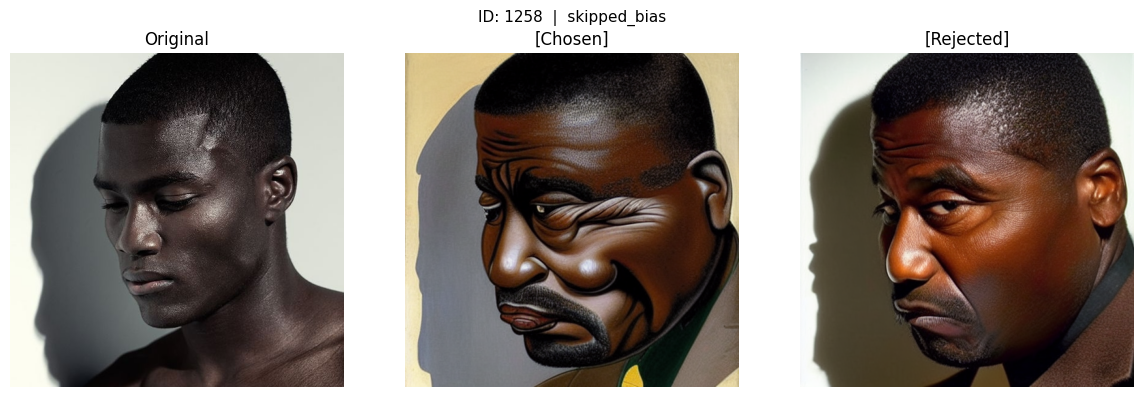

KeyboardInterrupt: 

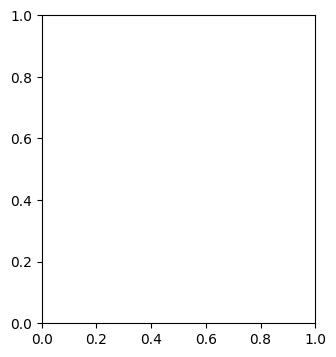

In [34]:
import time
import gc
import torch

# ── 1. Вспомогательная ───────────────────────────────────────────────────────
def get_free_vram_gb(device_idx: int = 0) -> float:
    free, _ = torch.cuda.mem_get_info(device_idx)
    return free / (1024 ** 3)

# ── 2. offload_pipe ───────────────────────────────────────────────────────────
def offload_pipe(pipe) -> None:
    for name in ["unet", "vae", "text_encoder", "controlnet"]:
        comp = getattr(pipe, name, None)
        if comp is not None and hasattr(comp, "to"):
            comp.to("cpu")
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize(0)
    free = get_free_vram_gb(0)
    print(f"✅ SD pipeline выгружен | Свободно cuda:0: {free:.2f} ГБ")

# ── 3. restore_pipe ───────────────────────────────────────────────────────────
def restore_pipe(
    pipe,
    device      : str = "cuda:0",
    max_retries : int = 10,
    wait_sec    : int = 30,
) -> bool:
    device_idx = int(device.split(":")[-1]) if ":" in device else 0
    components = ["unet", "vae", "text_encoder", "controlnet"]

    for attempt in range(1, max_retries + 1):
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize(device_idx)

        free_gb = get_free_vram_gb(device_idx)
        print(f"\n  🔄 restore_pipe: попытка {attempt}/{max_retries} "
              f"| Свободно {device}: {free_gb:.2f} ГБ")

        if free_gb < 2.0:
            print(f"  ⏳ Памяти < 2 ГБ. Ждём {wait_sec} сек...")
            time.sleep(wait_sec)
            continue

        loaded  = []
        success = True

        for name in components:
            comp = getattr(pipe, name, None)
            if comp is None or not hasattr(comp, "to"):
                continue
            try:
                comp.to(device)
                loaded.append(name)
            except (RuntimeError, torch.cuda.OutOfMemoryError) as e:
                if "out of memory" in str(e).lower():
                    print(f"  ⚠️  OOM при загрузке '{name}' "
                          f"(уже загружено: {loaded})")
                    success = False
                    break
                else:
                    raise

        if success:
            gc.collect()
            torch.cuda.empty_cache()
            free_after = get_free_vram_gb(device_idx)
            print(f"✅ pipe восстановлен на {device} "
                  f"| Осталось: {free_after:.2f} ГБ")
            return True

        # Откат
        print(f"  🔙 Откат: возвращаем {loaded} на CPU...")
        for name in loaded:
            comp = getattr(pipe, name, None)
            if comp is not None:
                try:
                    comp.to("cpu")
                except Exception:
                    pass
        gc.collect()
        torch.cuda.empty_cache()
        print(f"  ⏳ Ждём {wait_sec} сек...")
        time.sleep(wait_sec)

    print(f"❌ restore_pipe: не удалось после {max_retries} попыток")
    return False

# ── 4. load_judge / unload_judge ─────────────────────────────────────────────
JUDGE_MODEL_ID = "Qwen/Qwen2-VL-7B-Instruct"

def load_judge():
    from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
    gc.collect()
    torch.cuda.empty_cache()
    print(f"  Загрузка судьи {JUDGE_MODEL_ID} → строго на cuda:3...")
    processor = AutoProcessor.from_pretrained(
        JUDGE_MODEL_ID,
        min_pixels=256 * 28 * 28,
        max_pixels=512 * 28 * 28,
    )
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        JUDGE_MODEL_ID,
        torch_dtype=torch.float16,
        device_map={"": "cuda:3"},
    )
    model.eval()
    print("✅ Судья загружен на cuda:3")
    return model, processor

def unload_judge(model, processor) -> None:
    try:
        model.to("cpu")
    except Exception:
        pass
    del model, processor
    gc.collect()
    for i in range(torch.cuda.device_count()):
        torch.cuda.empty_cache()
        torch.cuda.synchronize(i)
    print("✅ Судья выгружен")
    for i in range(torch.cuda.device_count()):
        print(f"   GPU {i}: {get_free_vram_gb(i):.2f} ГБ свободно")

# ── 5. run_full_pipeline ──────────────────────────────────────────────────────
def run_full_pipeline(
    dataset_dir   : Path,
    output_dir    : Path,
    pipe,
    aggregator    : "MediaPipeFaceAggregator",
    groups        : dict,
    batch_size    : int   = 50,
    n_cycles      : int   = 3,
    min_pairs_dpo : int   = 10,
    warp_strength : float = 1.5,
    dpo_save_dir  : str   = "dpo_checkpoints",
) -> None:
    shown_ids: set = set()

    for cycle in range(1, n_cycles + 1):
        print(f"\n{'='*60}")
        print(f"  ЦИКЛ {cycle}/{n_cycles}")
        print(f"{'='*60}")

        for i in range(torch.cuda.device_count()):
            print(f"  GPU {i}: {get_free_vram_gb(i):.2f} ГБ свободно")

        shown_ids = preview_recent_caricatures(
            output_dir, n=4, cycle=cycle, shown_ids=shown_ids
        )

        # ── Генерация ──────────────────────────────────────────────────
        print(f"\n  Генерация пар (батч {batch_size})...")
        try:
            generated = run_dataset_generation(
                dataset_dir   = dataset_dir,
                output_dir    = output_dir,
                pipe          = pipe,
                aggregator    = aggregator,
                groups        = groups,
                max_images    = batch_size,
                warp_strength = warp_strength,
            )
        except (RuntimeError, torch.cuda.OutOfMemoryError) as e:
            if "out of memory" in str(e).lower():
                print(f"❌ OOM при генерации. Пропускаем цикл {cycle}.")
                gc.collect()
                torch.cuda.empty_cache()
                continue
            raise

        # ── Проверяем pending ──────────────────────────────────────────
        manifest_path = output_dir / "manifest.json"
        pending_count = 0
        if manifest_path.exists():
            with open(manifest_path, encoding="utf-8") as f:
                current_manifest = json.load(f)
            pending_count = sum(
                1 for m in current_manifest
                if m.get("judge") == "pending"
            )

        if generated == 0 and pending_count == 0:
            print("\n  Нет новых данных. Завершаем.")
            break

        # ── Судья ──────────────────────────────────────────────────────
        print("\n  Выгрузка SD из VRAM (cuda:0)...")
        offload_pipe(pipe)

        judge_model     = None
        judge_processor = None
        judge_ok        = False

        try:
            judge_model, judge_processor = load_judge()
            run_judge_phase(output_dir, judge_model, judge_processor)
            judge_ok = True
        except (RuntimeError, torch.cuda.OutOfMemoryError) as e:
            if "out of memory" in str(e).lower():
                print(f"❌ OOM при работе судьи: {e}")
            else:
                print(f"❌ Ошибка судьи: {e}")
        finally:
            if judge_model is not None:
                try:
                    unload_judge(judge_model, judge_processor)
                except Exception as e:
                    print(f"  ⚠️ Ошибка при выгрузке судьи: {e}")
                    del judge_model, judge_processor
                    gc.collect()
                    torch.cuda.empty_cache()

        # ── Восстанавливаем pipe ───────────────────────────────────────
        print("\n  Восстановление SD pipeline на cuda:0...")
        pipe_ok = restore_pipe(
            pipe,
            device      = "cuda:0",
            max_retries = 10,
            wait_sec    = 30,
        )

        if not pipe_ok:
            print("⚠️  Пропускаем DPO: не удалось восстановить pipe.")
            print(f"  Цикл {cycle} завершён (без DPO)")
            continue

        # ── DPO ────────────────────────────────────────────────────────
        if not judge_ok:
            print("  DPO пропущен: судья не завершил оценку")
            print(f"  Цикл {cycle} завершён")
            continue

        dpo_dataset = build_dpo_dataset(
            output_dir, min_pairs=min_pairs_dpo
        )

        if dpo_dataset is not None and len(dpo_dataset) > 0:
            try:
                metrics = run_dpo_training(
                    dpo_dataset = dpo_dataset,
                    pipe        = pipe,
                    cycle       = cycle,
                    save_dir    = dpo_save_dir,
                )
                if metrics is not None:
                    TRAINING_LOG.append(metrics)
                    print("\n  Динамика DPO loss:")
                    print(f"  {'Цикл':>5} | {'dpo_loss':>9} | "
                          f"{'margin':>8} | {'пар':>6}")
                    print(f"  {'-'*38}")
                    for m in TRAINING_LOG:
                        print(
                            f"  {m['cycle']:>5} | "
                            f"{m['mean_dpo_loss']:>9.4f} | "
                            f"{m['mean_margin']:>8.4f} | "
                            f"{m['n_pairs']:>6}"
                        )
            except (RuntimeError, torch.cuda.OutOfMemoryError) as e:
                if "out of memory" in str(e).lower():
                    print(f"❌ OOM при DPO. Освобождаем память...")
                    gc.collect()
                    torch.cuda.empty_cache()
                else:
                    raise
        else:
            print(f"\n  DPO пропущен: нужно минимум {min_pairs_dpo} пар")

        print(f"\n  Цикл {cycle} завершён")

    print(f"\n{'='*60}")
    print("  ФИНАЛЬНЫЙ PREVIEW")
    print(f"{'='*60}")
    preview_recent_caricatures(
        output_dir, n=6, cycle=n_cycles, shown_ids=shown_ids
    )
    print("\n  Все циклы завершены!")

print("✅ Все функции переопределены в одной ячейке")

# ── Запуск ────────────────────────────────────────────────────────────────────
run_full_pipeline(
    dataset_dir   = DATASET_DIR,
    output_dir    = OUTPUT_DIR,
    pipe          = pipe,
    aggregator    = aggregator,
    groups        = groups,
    batch_size    = 100,
    n_cycles      = 15,
    min_pairs_dpo = 10,
    warp_strength = 1.5,
    dpo_save_dir  = "dpo_checkpoints",
)

In [ ]:
# %%
# Полная очистка старых артефактов генерации и обучения.
# Удаляет:
#   1) dpo_dataset/              — все сгенерированные пары + manifest.json
#   2) artifacts/controlnet/prompt/ — все JSON/картинки от warp_stub / модуля коллеги
#   3) dpo_checkpoints/          — все чекпоинты DPO
#   4) очищает TRAINING_LOG
#
# После этого пайплайн можно запускать "с нуля".
'''
import shutil
from pathlib import Path

def safe_remove_dir(path: Path) -> None:
    """Безопасно удаляет директорию целиком, если она существует."""
    path = Path(path)
    if path.exists():
        shutil.rmtree(path, ignore_errors=True)
        print(f"🗑 Удалено: {path}")
    else:
        print(f"ℹ️ Не найдено, пропуск: {path}")

def reset_project_state(
    output_dir      : Path,
    warp_output_dir : Path,
    checkpoints_dir : Path | str = "dpo_checkpoints",
) -> None:
    """
    Полностью сбрасывает состояние проекта.

    Параметры
    ----------
    output_dir      : папка dpo_dataset
    warp_output_dir : папка artifacts/controlnet/prompt
    checkpoints_dir : папка с DPO чекпоинтами
    """
    checkpoints_dir = Path(checkpoints_dir)

    print("⚠️ Начинаем полную очистку проекта...\n")

    # 1. Удаляем датасет пар
    safe_remove_dir(output_dir)

    # 2. Удаляем артефакты заглушки / модуля варпа
    safe_remove_dir(warp_output_dir)

    # 3. Удаляем чекпоинты
    safe_remove_dir(checkpoints_dir)

    # 4. Пересоздаём пустую выходную папку
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f"📁 Создана пустая папка: {output_dir}")

    # 5. Очищаем лог обучения если он существует
    if "TRAINING_LOG" in globals():
        TRAINING_LOG.clear()
        print("🧹 TRAINING_LOG очищен")

    gc.collect()
    torch.cuda.empty_cache()

    print("\n✅ Состояние проекта полностью сброшено.")
    print("Теперь можно запускать пайплайн заново на чистых данных.")


# ──────────────────────────────────────────────────────────────────────
# ЗАПУСК ОЧИСТКИ
# ──────────────────────────────────────────────────────────────────────

reset_project_state(
    output_dir      = OUTPUT_DIR,
    warp_output_dir = Path("artifacts/controlnet/prompt"),
    checkpoints_dir = "dpo_checkpoints",
)'''

In [ ]:
# %%
# Диагностическая ячейка — запустите перед DPO

import torch

for i in range(torch.cuda.device_count()):
    total  = torch.cuda.get_device_properties(i).total_memory / 1024**3
    used   = torch.cuda.memory_allocated(i) / 1024**3
    cached = torch.cuda.memory_reserved(i) / 1024**3
    print(f"GPU {i}: total={total:.1f}GB | allocated={used:.1f}GB | cached={cached:.1f}GB")

✅ Библиотеки загружены
✅ Конфиг задан | GPU: cuda:1 | Свободно: 20.40 ГБ
✅ Датаклассы определены
Чекпоинт: dpo_checkpoints/cycle_002
⏳ Eval pipeline → cuda:1 | Свободно: 20.40 ГБ


'_ssl.c:975: The handshake operation timed out' thrown while requesting HEAD https://huggingface.co/lllyasviel/control_v11p_sd15_canny/resolve/115a470d547982438f70198e353a921996e2e819/diffusion_pytorch_model.safetensors.index.json
Retrying in 1s [Retry 1/5].
Loading pipeline components...: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00,  7.86it/s]
image_encoder is not loaded since `image_encoder_folder=None` passed. You will not be able to use `ip_adapter_image` when calling the pipeline with IP-Adapter.Use `ip_adapter_image_embeds` to pass pre-generated image embedding instead.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys a

  Чекпоинт: cycle_002
✅ Pipeline готов | Свободно: 17.88 ГБ
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/kseno/jupyterhub/venv/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
✅ LPIPS → cuda:1
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '1', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'HEURISTIC', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '2147483648', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kSameAsRequested', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'us

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:04<00:00,  6.01it/s]


  cos=0.000 l2=2.000 ssim=0.163 lpips=0.551 sharp=1135 art=2 ❌

[2/10] 2558.jpg | free: 20.44 ГБ


...

  cos=0.000 l2=2.000 ssim=0.308 lpips=0.390 sharp=1444 art=1 ❌

[7/10] 6381.jpg | free: 20.37 ГБ
  ❌ Лицо не найдено

[8/10] 1568.jpg | free: 20.37 ГБ


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:04<00:00,  5.98it/s]


  cos=0.000 l2=2.000 ssim=0.206 lpips=0.479 sharp=550 art=1 ❌

[9/10] 5285.jpg | free: 20.37 ГБ
  ❌ Лицо не найдено

[10/10] 2572.jpg | free: 20.37 ГБ


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:04<00:00,  6.68it/s]


  cos=0.000 l2=2.000 ssim=0.271 lpips=0.317 sharp=1016 art=2 ❌

  ОТЧЁТ ОЦЕНКИ МОДЕЛИ ШАРЖЕЙ
  Изображений : 7  |  GPU: cuda:1

── ИДЕНТИЧНОСТЬ ──────────────────────────────────────
  FaceID Cosine Sim (mean)     0.0744 ± 0.1303       ↑ выше = лучше
  FaceID L2 Distance           1.8280                ↓ ниже = ближе к оригиналу
  % identity_ok                14.3%                 ↑ > 70% хорошо
  % face detected              14.3%                 ↑ > 80% хорошо

── СТРУКТУРНОЕ СХОДСТВО ──────────────────────────────
  SSIM                         0.3152                ↕ 0.3–0.65 оптимум для шаржа
  MS-SSIM                      0.3105                ↕ 0.3–0.65 оптимум

── ПЕРЦЕПТИВНЫЕ И ПИКСЕЛЬНЫЕ ─────────────────────────
  LPIPS                        0.3953                ↕ 0.3–0.7 оптимум
  MAE                          37.54                 ↑ 15–60 оптимум
  PSNR дБ                      13.65                 ↓ 15–28 оптимум

── ДЕФОРМАЦИЯ ────────────────────────────────────────
  

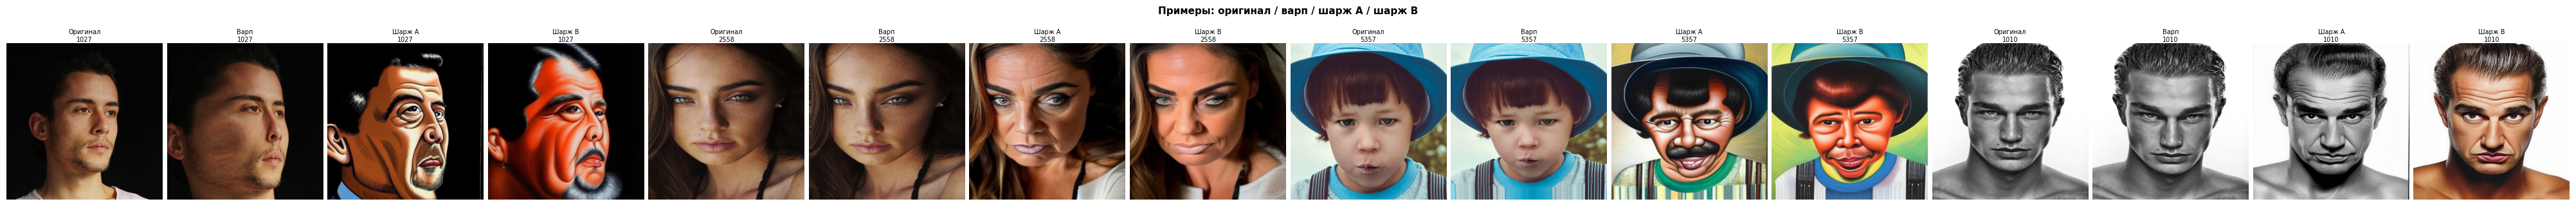

✅ Примеры изображений сохранены (table0_examples.png)


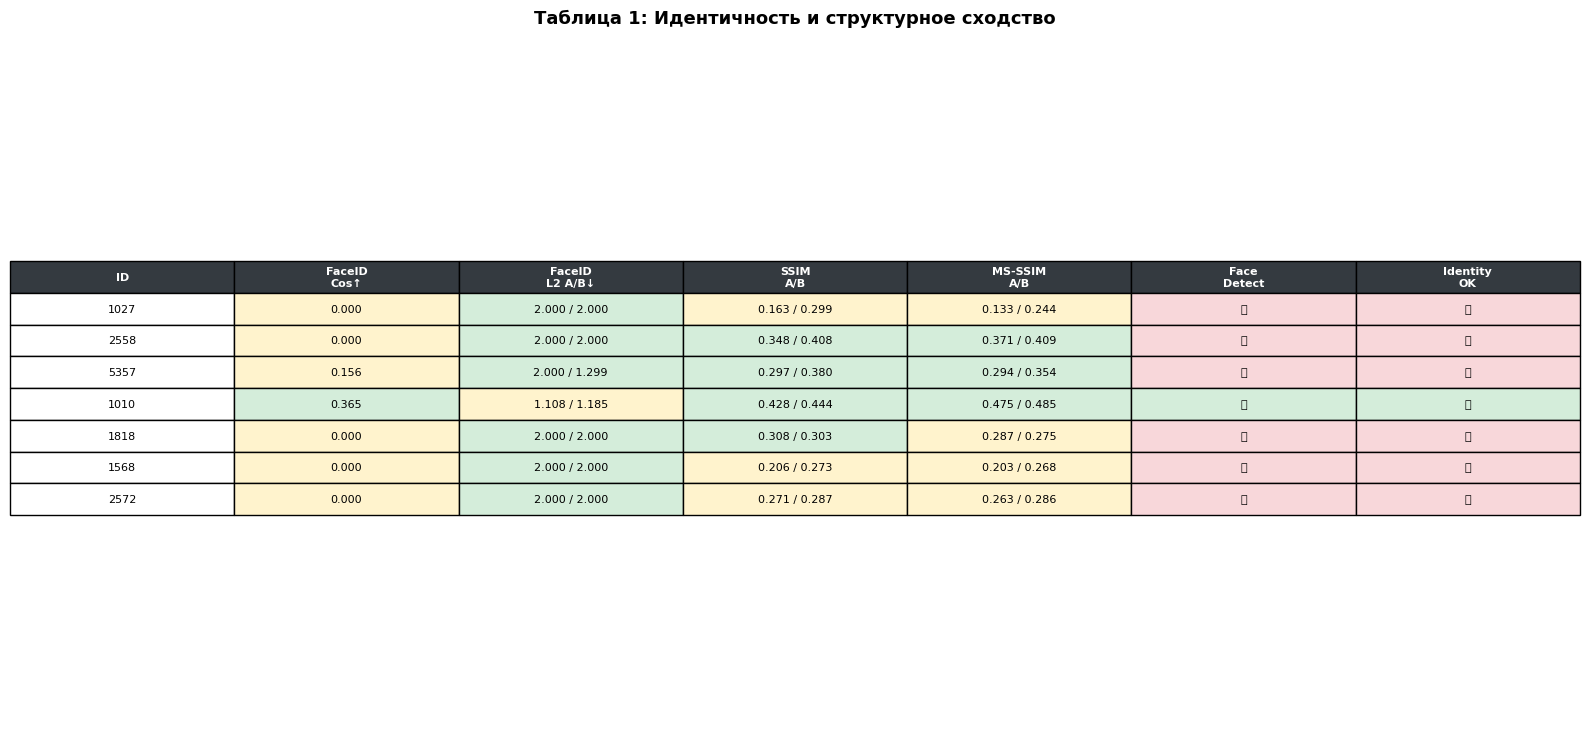

✅ Таблица 1 сохранена


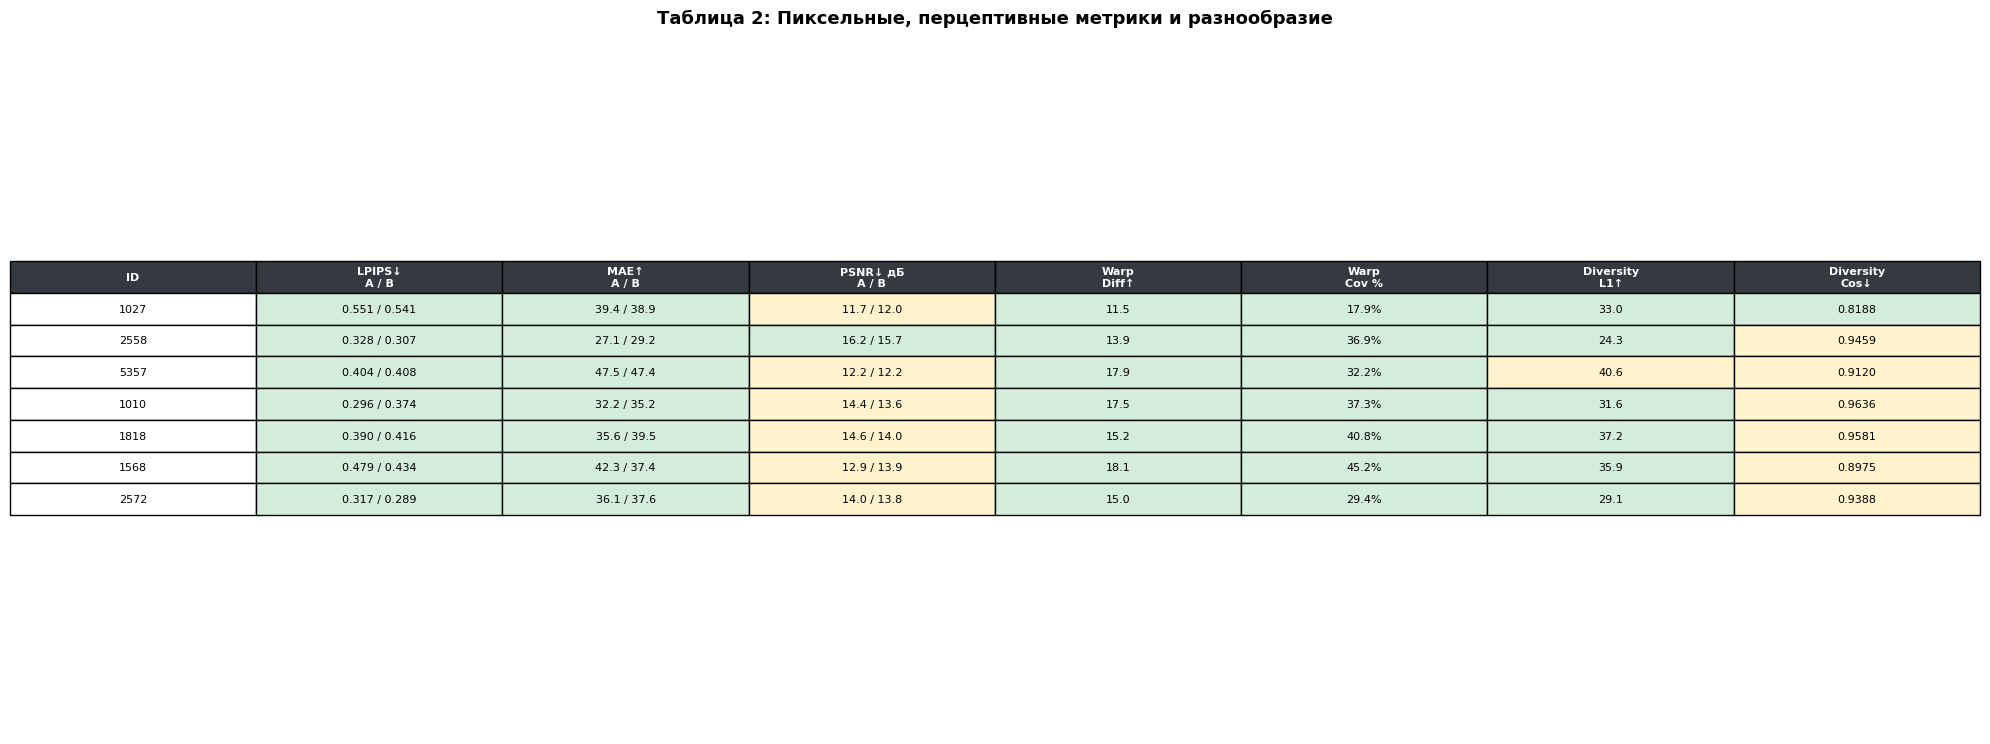

✅ Таблица 2 сохранена


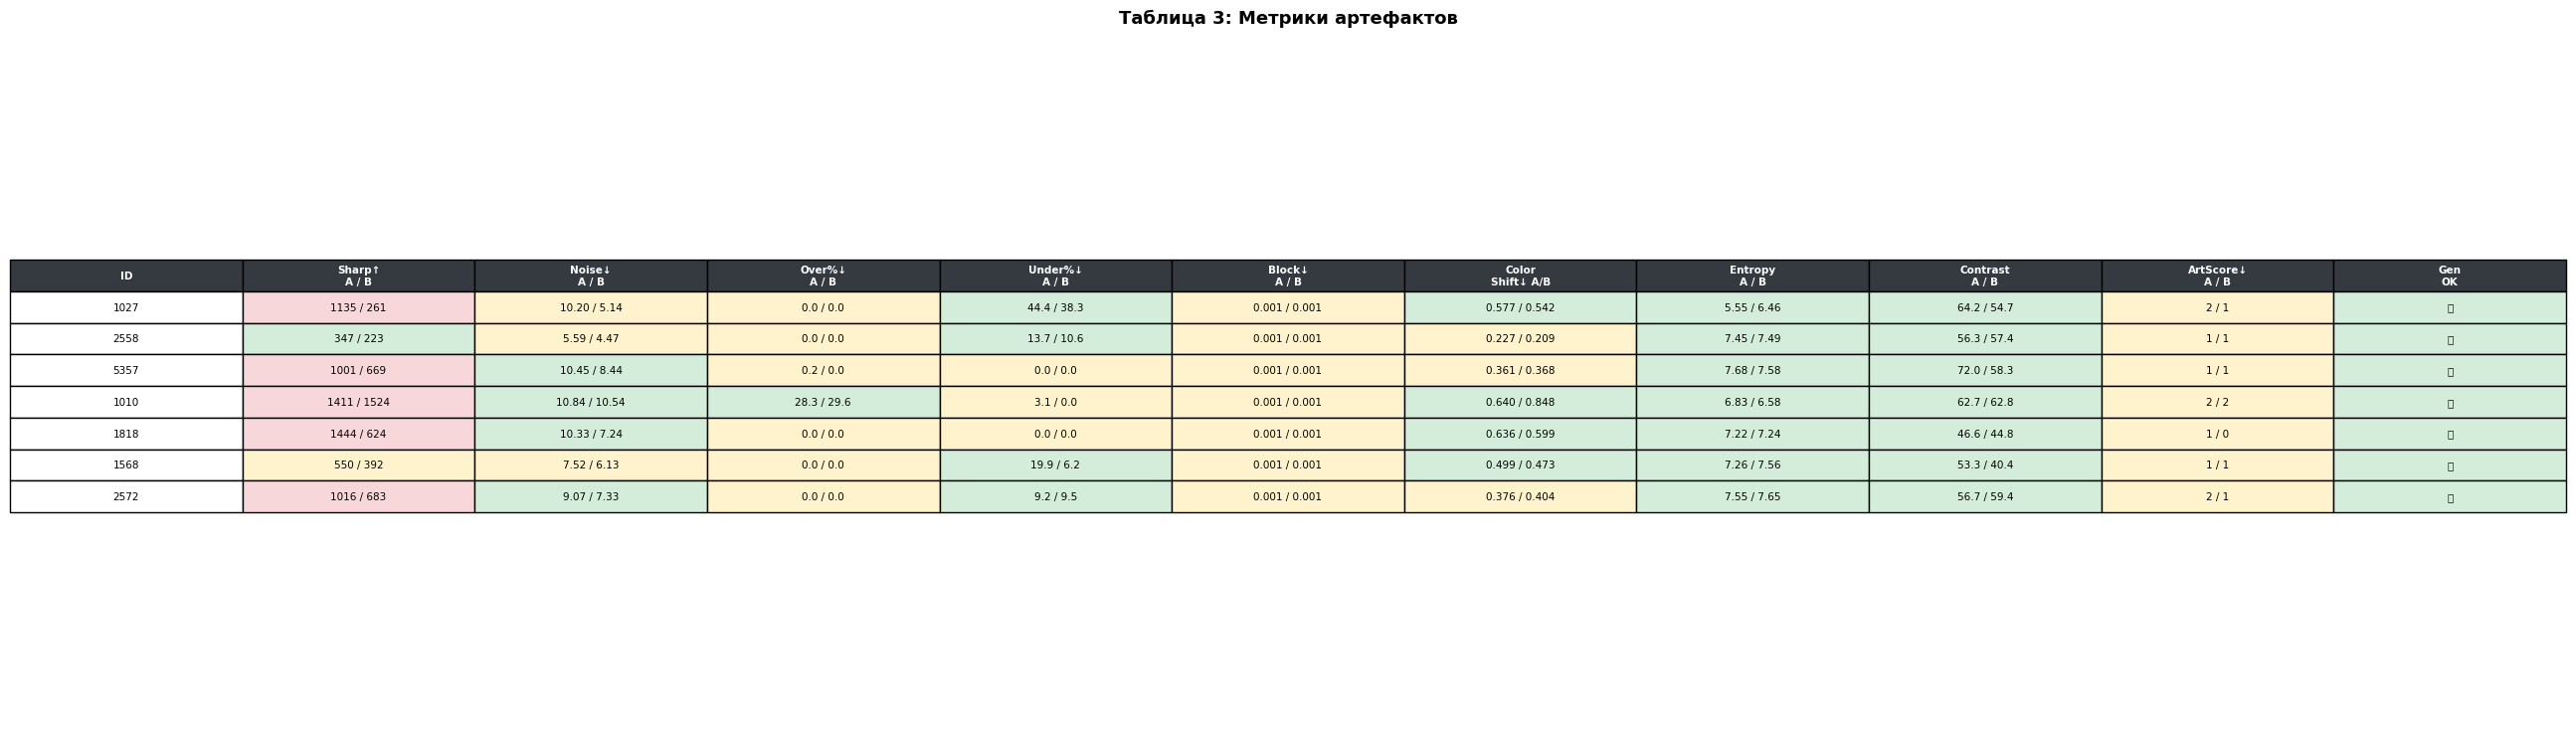

✅ Таблица 3 сохранена


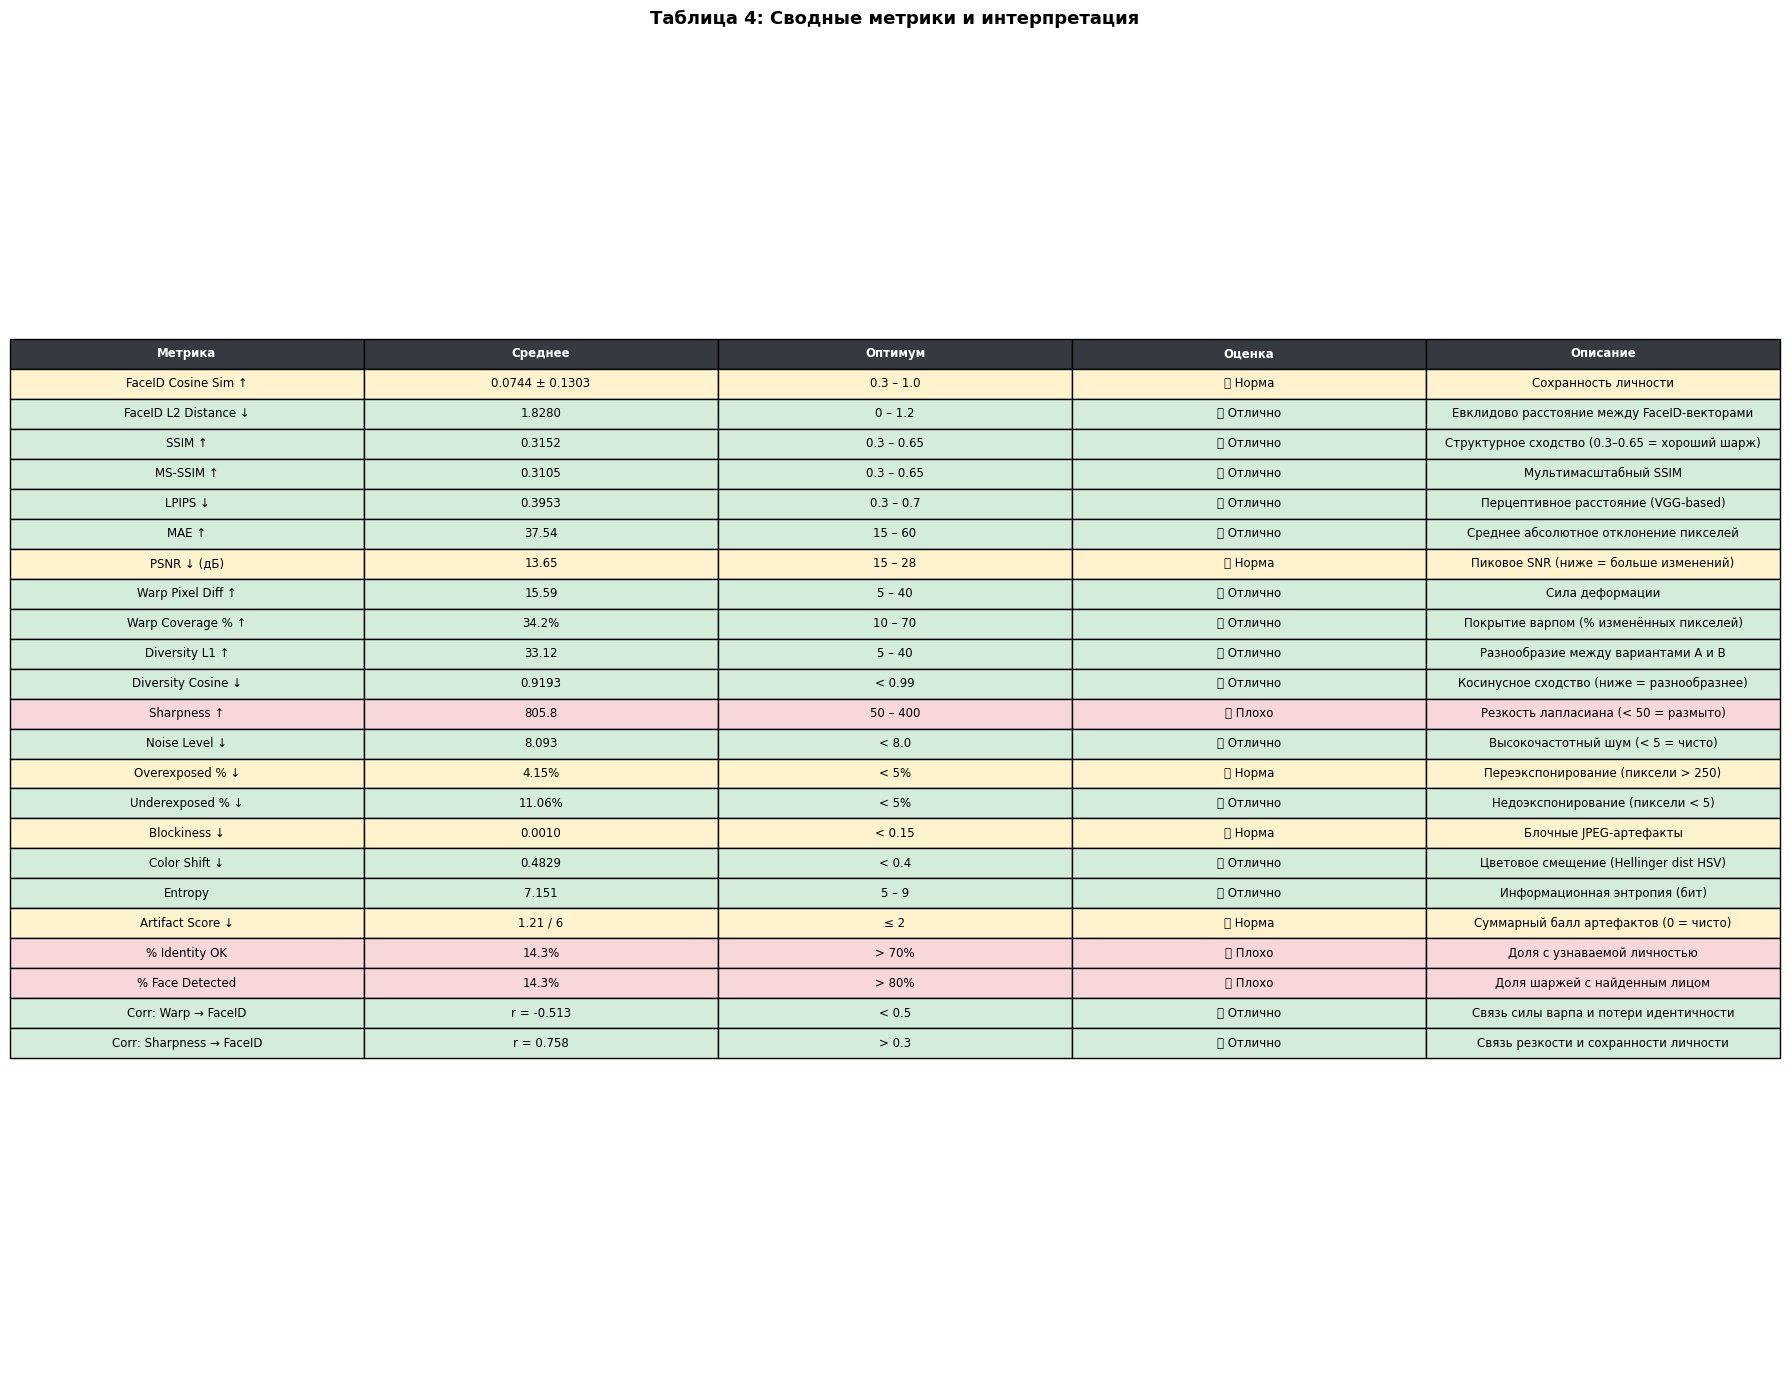

✅ Таблица 4 (сводная) сохранена


In [58]:
# ══════════════════════════════════════════════════════════════════════
# ПОЛНЫЙ БЛОК ОЦЕНКИ КАЧЕСТВА МОДЕЛИ — всё на GPU:1
# ══════════════════════════════════════════════════════════════════════

import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "lpips", "scikit-image", "scipy"])

import os, gc, json, random, warnings
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import colors as mcolors
from PIL import Image
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from skimage.metrics import structural_similarity as ssim_fn
from skimage.filters import laplace
from scipy.stats import pearsonr, entropy as scipy_entropy
from scipy.fft import fft2, fftshift
import lpips as lpips_lib
from insightface.app import FaceAnalysis
from diffusers import (
    StableDiffusionControlNetImg2ImgPipeline,
    ControlNetModel,
    EulerAncestralDiscreteScheduler,
)

warnings.filterwarnings("ignore")
print("✅ Библиотеки загружены")

# ══════════════════════════════════════════════════════════════════════
# КОНФИГ
# ══════════════════════════════════════════════════════════════════════

EVAL_GPU    = 1
EVAL_DEVICE = f"cuda:{EVAL_GPU}"

EVAL_CONFIG = {
    "n_images"           : 10,
    "shuffle"            : True,
    "sample_seed"        : 42,
    "gen_seeds"          : [67, 999, 1234],
    "identity_threshold" : 0.3,
    "warp_diff_min"      : 5.0,
    # Пороги для метрик артефактов
    "artifact_blur_thresh"    : 50.0,   # ниже = размыто
    "artifact_noise_thresh"   : 8.0,    # выше = шум
    "artifact_overexp_thresh" : 250,    # пикселей со значением > 250
    "artifact_underexp_thresh": 5,      # пикселей со значением < 5
    "artifact_block_thresh"   : 0.15,   # блочность (JPEG-артефакты)
}

EVAL_DIR = OUTPUT_DIR / "_evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

print(f"✅ Конфиг задан | GPU: {EVAL_DEVICE} | "
      f"Свободно: {get_free_vram_gb(EVAL_GPU):.2f} ГБ")

# ══════════════════════════════════════════════════════════════════════
# ДАТАКЛАСС МЕТРИК
# ══════════════════════════════════════════════════════════════════════

@dataclass
class ImageMetrics:
    image_id : str

    # ── Идентичность ─────────────────────────────────────────────────
    # Cosine similarity между FaceID-векторами оригинала и шаржа
    # Диапазон 0–1, выше = лучше сохранена личность
    faceid_cos_sim_A    : float = 0.0
    faceid_cos_sim_B    : float = 0.0
    faceid_cos_sim_mean : float = 0.0

    # L2-расстояние между FaceID-векторами (евклидово)
    # Диапазон 0–∞, ниже = ближе к оригиналу
    faceid_l2_dist_A    : float = 0.0
    faceid_l2_dist_B    : float = 0.0

    # ── Структурное сходство ─────────────────────────────────────────
    # SSIM: 0–1, оптимум для шаржа 0.3–0.65
    ssim_A              : float = 0.0
    ssim_B              : float = 0.0

    # MS-SSIM: мультимасштабный SSIM, точнее обычного
    ms_ssim_A           : float = 0.0
    ms_ssim_B           : float = 0.0

    # ── Перцептивные метрики ─────────────────────────────────────────
    # LPIPS: перцептивное расстояние, оптимум 0.3–0.7
    lpips_A             : float = 0.0
    lpips_B             : float = 0.0

    # ── Пиксельные метрики ───────────────────────────────────────────
    # MAE: среднее абсолютное отклонение пикселей
    mae_A               : float = 0.0
    mae_B               : float = 0.0

    # PSNR: пиковое соотношение сигнал/шум (дБ), ниже = больше изменений
    psnr_A              : float = 0.0
    psnr_B              : float = 0.0

    # ── Метрики деформации ───────────────────────────────────────────
    warp_pixel_diff     : float = 0.0
    # Процент пикселей изменённых варпом более чем на порог
    warp_coverage_pct   : float = 0.0

    # ── Разнообразие между вариантами ────────────────────────────────
    diversity_l1        : float = 0.0   # L1 между шаржами A и B
    diversity_cosine    : float = 0.0   # Cosine similarity между A и B

    # ── Метрики артефактов ───────────────────────────────────────────
    # Резкость (Laplacian variance): низкая = размытость
    # Норма: 100–800 для нормальных фото, <50 = размыто
    sharpness_A         : float = 0.0
    sharpness_B         : float = 0.0

    # Уровень шума (оценка через высокочастотные компоненты)
    # Норма: <5.0 для чистых изображений
    noise_level_A       : float = 0.0
    noise_level_B       : float = 0.0

    # Переэкспонирование: % пикселей > 250
    overexp_pct_A       : float = 0.0
    overexp_pct_B       : float = 0.0

    # Недоэкспонирование: % пикселей < 5
    underexp_pct_A      : float = 0.0
    underexp_pct_B      : float = 0.0

    # Блочность (JPEG/сеточные артефакты): спектральный анализ
    blockiness_A        : float = 0.0
    blockiness_B        : float = 0.0

    # Цветовое смещение: разница в распределении цветов HSV
    color_shift_A       : float = 0.0
    color_shift_B       : float = 0.0

    # Энтропия изображения: битрейт информации
    # Норма: 6–8 для естественных изображений
    entropy_A           : float = 0.0
    entropy_B           : float = 0.0

    # Контраст лица (std яркости в roi лица)
    face_contrast_A     : float = 0.0
    face_contrast_B     : float = 0.0

    # Суммарный балл артефактов (0–6, меньше = чище)
    artifact_score_A    : int   = 0
    artifact_score_B    : int   = 0

    # ── Флаги детекции ───────────────────────────────────────────────
    face_detected_A     : bool  = False
    face_detected_B     : bool  = False

    # ── Итоговые флаги ───────────────────────────────────────────────
    identity_ok         : bool  = False
    warp_ok             : bool  = False
    generation_ok       : bool  = False


@dataclass
class AggregateMetrics:
    n_total                  : int   = 0
    # Идентичность
    mean_faceid_cos_sim      : float = 0.0
    std_faceid_cos_sim       : float = 0.0
    mean_faceid_l2_dist      : float = 0.0
    # Структура
    mean_ssim                : float = 0.0
    mean_ms_ssim             : float = 0.0
    # Перцептивные
    mean_lpips               : float = 0.0
    # Пиксельные
    mean_mae                 : float = 0.0
    mean_psnr                : float = 0.0
    # Деформация
    mean_warp_diff           : float = 0.0
    mean_warp_coverage       : float = 0.0
    # Разнообразие
    mean_diversity_l1        : float = 0.0
    mean_diversity_cosine    : float = 0.0
    # Артефакты
    mean_sharpness           : float = 0.0
    mean_noise_level         : float = 0.0
    mean_overexp_pct         : float = 0.0
    mean_underexp_pct        : float = 0.0
    mean_blockiness          : float = 0.0
    mean_color_shift         : float = 0.0
    mean_entropy             : float = 0.0
    mean_artifact_score      : float = 0.0
    # Проценты
    pct_identity_ok          : float = 0.0
    pct_face_detected        : float = 0.0
    pct_warp_ok              : float = 0.0
    # Корреляции
    corr_warp_vs_faceid      : float = 0.0
    corr_ssim_vs_lpips       : float = 0.0
    corr_sharpness_vs_faceid : float = 0.0
    all_metrics              : List[ImageMetrics] = field(default_factory=list)


print("✅ Датаклассы определены")

# ══════════════════════════════════════════════════════════════════════
# ЗАГРУЗКА PIPELINE И МОДЕЛЕЙ НА GPU:1
# ══════════════════════════════════════════════════════════════════════

def _insightface_providers(gpu_idx: int) -> list:
    return [
        (
            "CUDAExecutionProvider",
            {
                "device_id":                 gpu_idx,
                "arena_extend_strategy":     "kSameAsRequested",
                "gpu_mem_limit":             2 * 1024 ** 3,
                "cudnn_conv_algo_search":    "HEURISTIC",
                "do_copy_in_default_stream": True,
            },
        ),
        "CPUExecutionProvider",
    ]


def load_eval_pipeline(
    checkpoint_dir : Optional[str] = None,
    device         : str           = EVAL_DEVICE,
) -> StableDiffusionControlNetImg2ImgPipeline:
    gc.collect(); torch.cuda.empty_cache()
    free_gb = get_free_vram_gb(EVAL_GPU)
    print(f"⏳ Eval pipeline → {device} | Свободно: {free_gb:.2f} ГБ")
    if free_gb < 8.0:
        raise RuntimeError(f"Мало памяти: {free_gb:.2f} ГБ < 8 ГБ")

    controlnet = ControlNetModel.from_pretrained(
        "lllyasviel/control_v11p_sd15_canny",
        torch_dtype=torch.float16, use_safetensors=True,
    ).to(device)

    eval_pipe = StableDiffusionControlNetImg2ImgPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        controlnet=controlnet, torch_dtype=torch.float16,
        safety_checker=None, requires_safety_checker=False,
    ).to(device)
    eval_pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(
        eval_pipe.scheduler.config
    )
    eval_pipe.load_ip_adapter(
        "h94/IP-Adapter-FaceID", subfolder=None,
        weight_name="ip-adapter-faceid_sd15.bin", image_encoder_folder=None,
    )
    eval_pipe.load_lora_weights(
        "h94/IP-Adapter-FaceID",
        weight_name="ip-adapter-faceid_sd15_lora.safetensors",
    )
    eval_pipe.fuse_lora(lora_scale=LORA_SCALE)
    eval_pipe.set_ip_adapter_scale(IP_ADAPTER_SCALE)

    if checkpoint_dir is not None:
        ckpt_path = Path(checkpoint_dir)
        if ckpt_path.exists():
            from peft import PeftModel
            print(f"  Чекпоинт: {ckpt_path.name}")
            eval_pipe.unet = PeftModel.from_pretrained(eval_pipe.unet, str(ckpt_path))
            eval_pipe.unet = eval_pipe.unet.merge_and_unload().to(device)
        else:
            print(f"  ⚠️ Чекпоинт не найден: {ckpt_path}")

    print(f"✅ Pipeline готов | Свободно: {get_free_vram_gb(EVAL_GPU):.2f} ГБ")
    return eval_pipe


def load_eval_models(device: str = EVAL_DEVICE):
    gpu_idx = int(device.split(":")[-1]) if ":" in device else 0
    gc.collect(); torch.cuda.empty_cache()

    lpips_model = lpips_lib.LPIPS(net="alex").to(device)
    lpips_model.eval()
    print(f"✅ LPIPS → {device}")

    face_eval = FaceAnalysis(name="buffalo_l",
                              providers=_insightface_providers(gpu_idx))
    face_eval.prepare(ctx_id=gpu_idx, det_size=(640, 640))

    eval_face_app = FaceAnalysis(name="buffalo_l",
                                  providers=_insightface_providers(gpu_idx))
    eval_face_app.prepare(ctx_id=gpu_idx, det_size=(640, 640))

    print(f"✅ InsightFace (x2) → {device} | "
          f"Свободно: {get_free_vram_gb(gpu_idx):.2f} ГБ")
    return lpips_model, face_eval, eval_face_app


_ckpt_root = Path("dpo_checkpoints")
EVAL_CHECKPOINT = None
if _ckpt_root.exists():
    _cycles = sorted(_ckpt_root.glob("cycle_*"))
    EVAL_CHECKPOINT = str(_cycles[-1]) if _cycles else None
print(f"Чекпоинт: {EVAL_CHECKPOINT or 'базовая модель'}")

eval_pipe                           = load_eval_pipeline(EVAL_CHECKPOINT, EVAL_DEVICE)
lpips_model, face_eval, eval_face_app = load_eval_models(EVAL_DEVICE)

# ══════════════════════════════════════════════════════════════════════
# ФУНКЦИИ ВЫЧИСЛЕНИЯ МЕТРИК
# ══════════════════════════════════════════════════════════════════════

# ── Идентичность ─────────────────────────────────────────────────────

def compute_faceid_metrics(
    face_eval : FaceAnalysis,
    img_orig  : np.ndarray,   # BGR
    img_caric : np.ndarray,   # BGR
) -> Tuple[float, float, bool]:
    """
    Возвращает (cosine_similarity, l2_distance, face_detected).
    Cosine sim нормированных векторов = dot product.
    L2: sqrt(sum((a-b)^2)), для нормированных векторов в [0, 2].
    """
    fo = face_eval.get(img_orig)
    fc = face_eval.get(img_caric)
    if not fo or not fc:
        return 0.0, 2.0, False
    emb_o = fo[0].normed_embedding
    emb_c = fc[0].normed_embedding
    cos   = float(np.clip(np.dot(emb_o, emb_c), 0.0, 1.0))
    l2    = float(np.linalg.norm(emb_o - emb_c))
    return cos, l2, True


# ── Структурные ──────────────────────────────────────────────────────

def compute_ssim_metric(
    img_a: Image.Image,
    img_b: Image.Image,
    size : int = 256,
) -> float:
    a = np.array(img_a.resize((size, size)).convert("L"))
    b = np.array(img_b.resize((size, size)).convert("L"))
    score, _ = ssim_fn(a, b, full=True)
    return float(score)


def compute_ms_ssim(
    img_a : Image.Image,
    img_b : Image.Image,
    size  : int = 256,
    levels: int = 3,
) -> float:
    """
    Упрощённый MS-SSIM: усредняем SSIM по нескольким масштабам.
    Полная реализация требует pytorch-msssim, здесь обходимся numpy.
    """
    scores = []
    for scale in range(levels):
        s = size // (2 ** scale)
        if s < 16:
            break
        scores.append(compute_ssim_metric(img_a, img_b, size=s))
    return float(np.mean(scores)) if scores else 0.0


# ── Перцептивные ─────────────────────────────────────────────────────

def compute_lpips_metric(
    lpips_model : lpips_lib.LPIPS,
    img_a       : Image.Image,
    img_b       : Image.Image,
    size        : int = 256,
) -> float:
    device = str(next(lpips_model.parameters()).device)
    def _t(img):
        arr = np.array(img.resize((size, size))).astype(np.float32) / 127.5 - 1.0
        return torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(device)
    with torch.no_grad():
        return float(lpips_model(_t(img_a), _t(img_b)).item())


# ── Пиксельные ───────────────────────────────────────────────────────

def compute_mae(img_a: Image.Image, img_b: Image.Image, size: int = 256) -> float:
    a = np.array(img_a.resize((size, size))).astype(float)
    b = np.array(img_b.resize((size, size))).astype(float)
    return float(np.abs(a - b).mean())


def compute_psnr(img_a: Image.Image, img_b: Image.Image, size: int = 256) -> float:
    """
    PSNR в дБ. Для шаржей ожидаем 15–28 дБ.
    Очень высокий (>35 дБ) означает слишком слабый шарж.
    """
    a = np.array(img_a.resize((size, size))).astype(float)
    b = np.array(img_b.resize((size, size))).astype(float)
    mse = np.mean((a - b) ** 2)
    if mse < 1e-10:
        return 100.0
    return float(10 * np.log10(255.0 ** 2 / mse))


# ── Разнообразие ─────────────────────────────────────────────────────

def compute_diversity_metrics(
    img_a: Image.Image,
    img_b: Image.Image,
    size : int = 256,
) -> Tuple[float, float]:
    """
    Возвращает (l1_distance, cosine_similarity) между A и B.
    Cosine между выровненными векторами пикселей.
    """
    a = np.array(img_a.resize((size, size))).astype(float).flatten()
    b = np.array(img_b.resize((size, size))).astype(float).flatten()
    l1  = float(np.abs(a - b).mean())
    cos = float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))
    return l1, cos


# ── Артефакты ────────────────────────────────────────────────────────

def compute_sharpness(img: Image.Image, size: int = 256) -> float:
    """
    Дисперсия лапласиана — классическая метрика резкости.
    < 50  → размытое
    50–200 → нормальное
    > 200 → очень резкое / шумное
    """
    gray = np.array(img.resize((size, size)).convert("L"), dtype=np.float32)
    return float(laplace(gray).var())


def compute_noise_level(img: Image.Image, size: int = 256) -> float:
    """
    Оценка уровня шума через разность между изображением
    и его размытой версией (высокочастотная составляющая).
    Норма: < 5.0 для чистых изображений.
    """
    gray    = np.array(img.resize((size, size)).convert("L"), dtype=np.float32)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    noise   = gray - blurred
    return float(np.std(noise))


def compute_exposure_metrics(img: Image.Image, size: int = 256) -> Tuple[float, float]:
    """
    Возвращает (overexposed_pct, underexposed_pct).
    Процент пикселей выше 250 и ниже 5 в grayscale.
    """
    gray = np.array(img.resize((size, size)).convert("L"))
    total = gray.size
    over  = float(np.sum(gray > 250) / total * 100)
    under = float(np.sum(gray < 5)   / total * 100)
    return over, under


def compute_blockiness(img: Image.Image, size: int = 256) -> float:
    """
    Оценка блочности через спектральный анализ (FFT).
    JPEG-артефакты проявляются в кратных частотах (8x8 блоки).
    Норма: < 0.1 для чистых изображений, > 0.15 = заметные блоки.
    """
    gray = np.array(img.resize((size, size)).convert("L"), dtype=np.float32)
    f    = np.abs(fftshift(fft2(gray)))
    f_log = np.log1p(f)

    # Энергия в частотах кратных 8 (характерно для блочных артефактов)
    h, w     = f_log.shape
    cy, cx   = h // 2, w // 2
    block_energy = 0.0
    total_energy = f_log.sum() + 1e-8
    step = size // 8   # 8x8 блок → частота size/8
    for ky in range(-cy, cy, step):
        for kx in range(-cx, cx, step):
            y, x = cy + ky, cx + kx
            if 0 <= y < h and 0 <= x < w:
                block_energy += f_log[y, x]
    return float(block_energy / total_energy)


def compute_color_shift(
    img_orig  : Image.Image,
    img_caric : Image.Image,
    size      : int = 256,
) -> float:
    """
    Разница в распределении цветов через Hellinger distance
    между гистограммами HSV (канал Hue).
    0 = идентичные цвета, 1 = полностью разные.
    """
    def _hue_hist(img):
        hsv  = cv2.cvtColor(np.array(img.resize((size, size))), cv2.COLOR_RGB2HSV)
        hist = cv2.calcHist([hsv], [0], None, [36], [0, 180]).flatten()
        hist = hist / (hist.sum() + 1e-8)
        return hist

    h1, h2 = _hue_hist(img_orig), _hue_hist(img_caric)
    # Hellinger distance
    hellinger = float(np.sqrt(1 - np.sum(np.sqrt(h1 * h2 + 1e-8))))
    return float(np.clip(hellinger, 0.0, 1.0))


def compute_entropy(img: Image.Image, size: int = 256) -> float:
    """
    Энтропия Шеннона изображения в битах.
    Норма: 6–8 для естественных изображений.
    < 5 = слишком однородное (мыльное), > 9 = шумное.
    """
    gray = np.array(img.resize((size, size)).convert("L"))
    hist = np.histogram(gray, bins=256, range=(0, 256))[0]
    hist = hist / (hist.sum() + 1e-8)
    return float(scipy_entropy(hist + 1e-8, base=2))


def compute_face_contrast(face_eval: FaceAnalysis, img_bgr: np.ndarray) -> float:
    faces = face_eval.get(img_bgr)
    if not faces:
        h, w = img_bgr.shape[:2]
        roi  = img_bgr[h//4:3*h//4, w//4:3*w//4]
    else:
        x1, y1, x2, y2 = faces[0].bbox.astype(int)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(img_bgr.shape[1], x2), min(img_bgr.shape[0], y2)
        roi = img_bgr[y1:y2, x1:x2]
    if roi.size == 0:
        return 0.0
    return float(np.std(cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)))


def compute_artifact_score(metrics: ImageMetrics, suffix: str, config: dict) -> int:
    """
    Суммарный балл артефактов (0–6, меньше = чище изображение).
    Каждый тип артефакта даёт +1.
    """
    score = 0
    sharp = getattr(metrics, f"sharpness_{suffix}")
    noise = getattr(metrics, f"noise_level_{suffix}")
    over  = getattr(metrics, f"overexp_pct_{suffix}")
    under = getattr(metrics, f"underexp_pct_{suffix}")
    block = getattr(metrics, f"blockiness_{suffix}")
    entr  = getattr(metrics, f"entropy_{suffix}")

    if sharp < config["artifact_blur_thresh"]:   score += 1  # размытость
    if noise > config["artifact_noise_thresh"]:  score += 1  # шум
    if over  > 5.0:                              score += 1  # переэкспонирование
    if under > 5.0:                              score += 1  # недоэкспонирование
    if block > config["artifact_block_thresh"]:  score += 1  # блочность
    if entr  < 5.0 or entr > 9.0:               score += 1  # аномальная энтропия
    return score


def build_face_embeds_on_device(face, device: str) -> torch.Tensor:
    cond   = torch.from_numpy(face.normed_embedding).unsqueeze(0).unsqueeze(0)
    uncond = torch.zeros_like(cond)
    return torch.cat([uncond, cond], dim=0).to(dtype=torch.float16, device=device)


print("✅ Все функции метрик определены")

# ══════════════════════════════════════════════════════════════════════
# ОЦЕНКА ОДНОГО ИЗОБРАЖЕНИЯ
# ══════════════════════════════════════════════════════════════════════

def evaluate_single_image(
    img_path      : Path,
    eval_pipe,
    aggregator    : "MediaPipeFaceAggregator",
    groups        : dict,
    eval_face_app : FaceAnalysis,
    lpips_model   : lpips_lib.LPIPS,
    face_eval     : FaceAnalysis,
    config        : dict,
    device        : str = EVAL_DEVICE,
) -> Optional[Tuple]:

    metrics = ImageMetrics(image_id=img_path.stem)

    # 1. Оригинал
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print(f"  ❌ imread вернул None"); return None
    orig_pil = Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

    # 2. Детекция лица
    faces = eval_face_app.get(img_bgr)
    if not faces:
        print(f"  ❌ Лицо не найдено"); return None
    face = sorted(
        faces,
        key=lambda f: (f.bbox[2]-f.bbox[0]) * (f.bbox[3]-f.bbox[1]),
        reverse=True,
    )[0]

    # 3. Варп (CPU)
    warp_result = run_warp_module(img_path, aggregator, groups, EVAL_DIR, strength=1.5)
    if warp_result is None:
        print(f"  ❌ Варп не удался"); return None
    warped_pil, positive_prompt, negative_prompt = warp_result

    # Метрики деформации
    metrics.warp_pixel_diff = compute_mae(orig_pil, warped_pil)
    orig_arr   = np.array(orig_pil.resize((256, 256))).astype(float)
    warped_arr = np.array(warped_pil.resize((256, 256))).astype(float)
    metrics.warp_coverage_pct = float(
        np.mean(np.abs(orig_arr - warped_arr) > 10) * 100
    )
    metrics.warp_ok = metrics.warp_pixel_diff >= config["warp_diff_min"]

    # 4. Кроп и Canny
    warped_crop, box = square_crop_around_face(warped_pil, face.bbox, size=CROP_SIZE)
    orig_crop        = orig_pil.crop(box).resize((CROP_SIZE, CROP_SIZE), Image.LANCZOS)
    canny_mask       = get_canny_mask(warped_crop)

    # 5. Face embeds → EVAL_DEVICE
    face_embeds = build_face_embeds_on_device(face, device=device)
    common_kwargs = dict(
        prompt                        = positive_prompt,
        negative_prompt               = negative_prompt,
        image                         = warped_crop,
        control_image                 = canny_mask,
        ip_adapter_image_embeds       = [face_embeds],
        num_inference_steps           = NUM_STEPS,
        strength                      = DENOISE_STRENGTH,
        guidance_scale                = GUIDANCE_SCALE,
        controlnet_conditioning_scale = CONTROLNET_WEIGHT,
        control_guidance_start        = CONTROLNET_START,
        control_guidance_end          = CONTROLNET_END,
    )

    # 6. Генерация
    carics = []
    for seed in config["gen_seeds"]:
        gen = torch.Generator(device=device).manual_seed(seed)
        out = eval_pipe(**common_kwargs, generator=gen).images[0]
        carics.append(out)
        gc.collect(); torch.cuda.empty_cache()

    del face_embeds
    gc.collect(); torch.cuda.empty_cache()

    caric_A      = carics[0]
    caric_B      = carics[1] if len(carics) > 1 else carics[0]
    caric_A_bgr  = cv2.cvtColor(np.array(caric_A), cv2.COLOR_RGB2BGR)
    caric_B_bgr  = cv2.cvtColor(np.array(caric_B), cv2.COLOR_RGB2BGR)
    orig_bgr_res = cv2.resize(img_bgr, (CROP_SIZE, CROP_SIZE), interpolation=cv2.INTER_AREA)

    # 7. FaceID метрики
    cos_A, l2_A, det_A = compute_faceid_metrics(face_eval, orig_bgr_res, caric_A_bgr)
    cos_B, l2_B, det_B = compute_faceid_metrics(face_eval, orig_bgr_res, caric_B_bgr)
    metrics.faceid_cos_sim_A  = cos_A
    metrics.faceid_cos_sim_B  = cos_B
    metrics.faceid_l2_dist_A  = l2_A
    metrics.faceid_l2_dist_B  = l2_B
    metrics.face_detected_A   = det_A
    metrics.face_detected_B   = det_B
    all_cos = []
    for c in carics:
        cos, _, det = compute_faceid_metrics(
            face_eval, orig_bgr_res,
            cv2.cvtColor(np.array(c), cv2.COLOR_RGB2BGR),
        )
        if det: all_cos.append(cos)
    metrics.faceid_cos_sim_mean = float(np.mean(all_cos)) if all_cos else 0.0
    metrics.identity_ok = metrics.faceid_cos_sim_mean >= config["identity_threshold"]

    # 8. Структурные
    metrics.ssim_A    = compute_ssim_metric(orig_crop, caric_A)
    metrics.ssim_B    = compute_ssim_metric(orig_crop, caric_B)
    metrics.ms_ssim_A = compute_ms_ssim(orig_crop, caric_A)
    metrics.ms_ssim_B = compute_ms_ssim(orig_crop, caric_B)

    # 9. Перцептивные
    metrics.lpips_A = compute_lpips_metric(lpips_model, orig_crop, caric_A)
    metrics.lpips_B = compute_lpips_metric(lpips_model, orig_crop, caric_B)

    # 10. Пиксельные
    metrics.mae_A  = compute_mae(orig_crop, caric_A)
    metrics.mae_B  = compute_mae(orig_crop, caric_B)
    metrics.psnr_A = compute_psnr(orig_crop, caric_A)
    metrics.psnr_B = compute_psnr(orig_crop, caric_B)

    # 11. Разнообразие
    metrics.diversity_l1, metrics.diversity_cosine = compute_diversity_metrics(
        caric_A, caric_B
    )

    # 12. Артефакты
    for suffix, caric, caric_bgr in [("A", caric_A, caric_A_bgr),
                                      ("B", caric_B, caric_B_bgr)]:
        setattr(metrics, f"sharpness_{suffix}",
                compute_sharpness(caric))
        setattr(metrics, f"noise_level_{suffix}",
                compute_noise_level(caric))
        over, under = compute_exposure_metrics(caric)
        setattr(metrics, f"overexp_pct_{suffix}",  over)
        setattr(metrics, f"underexp_pct_{suffix}", under)
        setattr(metrics, f"blockiness_{suffix}",
                compute_blockiness(caric))
        setattr(metrics, f"color_shift_{suffix}",
                compute_color_shift(orig_crop, caric))
        setattr(metrics, f"entropy_{suffix}",
                compute_entropy(caric))
        setattr(metrics, f"face_contrast_{suffix}",
                compute_face_contrast(face_eval, caric_bgr))
        setattr(metrics, f"artifact_score_{suffix}",
                compute_artifact_score(metrics, suffix, config))

    metrics.generation_ok = (
        metrics.face_contrast_A > 5.0 and
        metrics.face_contrast_B > 5.0 and
        metrics.faceid_cos_sim_mean < 0.99 and
        metrics.artifact_score_A <= 2 and
        metrics.artifact_score_B <= 2
    )

    # 13. Сохранение
    save_dir = EVAL_DIR / img_path.stem
    save_dir.mkdir(parents=True, exist_ok=True)
    orig_crop.save(save_dir   / "original_crop.png")
    warped_crop.save(save_dir / "warped_crop.png")
    canny_mask.save(save_dir  / "canny.png")
    for seed, c in zip(config["gen_seeds"], carics):
        c.save(save_dir / f"caricature_seed{seed}.png")

    return metrics, carics, orig_crop, warped_crop


print("✅ evaluate_single_image определена")

# ══════════════════════════════════════════════════════════════════════
# АГРЕГАЦИЯ
# ══════════════════════════════════════════════════════════════════════

def _mean(lst):
    return float(np.mean(lst)) if lst else 0.0

def aggregate_metrics(all_metrics: List[ImageMetrics]) -> AggregateMetrics:
    agg = AggregateMetrics(n_total=len(all_metrics), all_metrics=all_metrics)
    if not all_metrics:
        return agg

    def avg(attr):
        return _mean([getattr(m, attr) for m in all_metrics])
    def avg2(a, b):
        return _mean([np.mean([getattr(m, a), getattr(m, b)]) for m in all_metrics])

    agg.mean_faceid_cos_sim      = avg("faceid_cos_sim_mean")
    agg.std_faceid_cos_sim       = float(np.std([m.faceid_cos_sim_mean for m in all_metrics]))
    agg.mean_faceid_l2_dist      = avg2("faceid_l2_dist_A", "faceid_l2_dist_B")
    agg.mean_ssim                = avg2("ssim_A",    "ssim_B")
    agg.mean_ms_ssim             = avg2("ms_ssim_A", "ms_ssim_B")
    agg.mean_lpips               = avg2("lpips_A",   "lpips_B")
    agg.mean_mae                 = avg2("mae_A",     "mae_B")
    agg.mean_psnr                = avg2("psnr_A",    "psnr_B")
    agg.mean_warp_diff           = avg("warp_pixel_diff")
    agg.mean_warp_coverage       = avg("warp_coverage_pct")
    agg.mean_diversity_l1        = avg("diversity_l1")
    agg.mean_diversity_cosine    = avg("diversity_cosine")
    agg.mean_sharpness           = avg2("sharpness_A",    "sharpness_B")
    agg.mean_noise_level         = avg2("noise_level_A",  "noise_level_B")
    agg.mean_overexp_pct         = avg2("overexp_pct_A",  "overexp_pct_B")
    agg.mean_underexp_pct        = avg2("underexp_pct_A", "underexp_pct_B")
    agg.mean_blockiness          = avg2("blockiness_A",   "blockiness_B")
    agg.mean_color_shift         = avg2("color_shift_A",  "color_shift_B")
    agg.mean_entropy             = avg2("entropy_A",      "entropy_B")
    agg.mean_artifact_score      = avg2("artifact_score_A", "artifact_score_B")
    agg.mean_face_contrast       = avg2("face_contrast_A",  "face_contrast_B") \
        if hasattr(all_metrics[0], "face_contrast_A") else 0.0

    agg.pct_identity_ok   = _mean([m.identity_ok     for m in all_metrics]) * 100
    agg.pct_face_detected = _mean([m.face_detected_A for m in all_metrics]) * 100
    agg.pct_warp_ok       = _mean([m.warp_ok         for m in all_metrics]) * 100

    faceid_list  = [m.faceid_cos_sim_mean for m in all_metrics]
    warp_list    = [m.warp_pixel_diff     for m in all_metrics]
    ssim_list    = [np.mean([m.ssim_A, m.ssim_B])  for m in all_metrics]
    lpips_list   = [np.mean([m.lpips_A, m.lpips_B]) for m in all_metrics]
    sharp_list   = [np.mean([m.sharpness_A, m.sharpness_B]) for m in all_metrics]

    if len(all_metrics) > 2:
        try: agg.corr_warp_vs_faceid, _      = pearsonr(warp_list,  [1-s for s in faceid_list])
        except: pass
        try: agg.corr_ssim_vs_lpips, _       = pearsonr(ssim_list,  lpips_list)
        except: pass
        try: agg.corr_sharpness_vs_faceid, _ = pearsonr(sharp_list, faceid_list)
        except: pass

    return agg


print("✅ aggregate_metrics определена")

# ══════════════════════════════════════════════════════════════════════
# КРАСИВЫЕ ТАБЛИЦЫ
# ══════════════════════════════════════════════════════════════════════

def _cell_color(val, lo_good, hi_good, invert=False):
    """
    Возвращает цвет ячейки:
      зелёный — значение в хорошем диапазоне
      жёлтый  — допустимо
      красный — плохо
    """
    in_range = lo_good <= val <= hi_good
    if invert:
        in_range = not in_range
    if in_range:
        return "#d4edda"   # зелёный
    margin = (hi_good - lo_good) * 0.5
    near   = (lo_good - margin) <= val <= (hi_good + margin)
    return "#fff3cd" if near else "#f8d7da"   # жёлтый / красный


def plot_metrics_tables(
    agg            : AggregateMetrics,
    sample_results : list,
    n_show         : int = 4,
) -> None:
    all_m  = agg.all_metrics
    n_show = min(n_show, len(sample_results))

    # ═══════════════════════════════════════════════════════════════
    # Рис. 0 — ОТДЕЛЬНАЯ фигура только для примеров изображений
    # ═══════════════════════════════════════════════════════════════
    if n_show > 0:
        n_cols   = n_show * 4           # orig / warp / caric_A / caric_B
        fig0, axes0 = plt.subplots(
            1, n_cols,
            figsize=(n_cols * 2.5, 3.5),
        )
        # Гарантируем, что axes0 всегда список
        if n_cols == 1:
            axes0 = [axes0]
        else:
            axes0 = list(axes0.flatten())

        fig0.suptitle("Примеры: оригинал / варп / шарж A / шарж B",
                      fontsize=11, fontweight="bold")

        for ci, (metrics, carics, orig_crop, warped_crop) in \
                enumerate(sample_results[:n_show]):
            panels = [
                ("Оригинал",  orig_crop),
                ("Варп",      warped_crop),
                ("Шарж A",    carics[0]),
                ("Шарж B",    carics[1] if len(carics) > 1 else carics[0]),
            ]
            for pi, (label, img) in enumerate(panels):
                ax  = axes0[ci * 4 + pi]
                # PIL Image → numpy для imshow
                arr = np.array(img.convert("RGB"))
                ax.imshow(arr)
                ax.set_title(
                    f"{label}\n{metrics.image_id[:8]}",
                    fontsize=7, pad=2,
                )
                ax.axis("off")
                # Рамка чтобы было видно границы
                for spine in ax.spines.values():
                    spine.set_visible(True)
                    spine.set_linewidth(0.5)

        plt.tight_layout(pad=0.5)
        plt.savefig(
            EVAL_DIR / "table0_examples.png",
            dpi=150, bbox_inches="tight",
        )
        plt.show()
        print("✅ Примеры изображений сохранены (table0_examples.png)")

    # ═══════════════════════════════════════════════════════════════
    # Рис. 1 — Таблица идентичности и структуры (без изображений)
    # ═══════════════════════════════════════════════════════════════
    fig1, ax1 = plt.subplots(
        figsize=(16, max(4, len(all_m) * 0.65 + 3))
    )
    ax1.axis("off")
    fig1.suptitle(
        "Таблица 1: Идентичность и структурное сходство",
        fontsize=13, fontweight="bold",
    )

    col_labels_1 = [
        "ID",
        "FaceID\nCos↑",
        "FaceID\nL2 A/B↓",
        "SSIM\nA/B",
        "MS-SSIM\nA/B",
        "Face\nDetect",
        "Identity\nOK",
    ]
    rows_1        = []
    cell_colors_1 = []

    for m in all_m:
        rows_1.append([
            m.image_id[:12],
            f"{m.faceid_cos_sim_mean:.3f}",
            f"{m.faceid_l2_dist_A:.3f} / {m.faceid_l2_dist_B:.3f}",
            f"{m.ssim_A:.3f} / {m.ssim_B:.3f}",
            f"{m.ms_ssim_A:.3f} / {m.ms_ssim_B:.3f}",
            "✅" if m.face_detected_A else "❌",
            "✅" if m.identity_ok     else "❌",
        ])
        cell_colors_1.append([
            "#ffffff",
            _cell_color(m.faceid_cos_sim_mean, 0.3,  1.0),
            _cell_color(
                np.mean([m.faceid_l2_dist_A, m.faceid_l2_dist_B]),
                0.0, 1.2, invert=True,
            ),
            _cell_color(np.mean([m.ssim_A,    m.ssim_B]),    0.3, 0.65),
            _cell_color(np.mean([m.ms_ssim_A, m.ms_ssim_B]), 0.3, 0.65),
            "#d4edda" if m.face_detected_A else "#f8d7da",
            "#d4edda" if m.identity_ok     else "#f8d7da",
        ])

    tbl1 = ax1.table(
        cellText    = rows_1,
        colLabels   = col_labels_1,
        cellColours = cell_colors_1,
        loc         = "center",
        cellLoc     = "center",
    )
    tbl1.auto_set_font_size(False)
    tbl1.set_fontsize(8)
    tbl1.scale(1, 1.6)
    # Заголовочная строка
    for j in range(len(col_labels_1)):
        tbl1[(0, j)].set_facecolor("#343a40")
        tbl1[(0, j)].set_text_props(color="white", fontweight="bold")

    plt.tight_layout()
    plt.savefig(
        EVAL_DIR / "table1_identity_structure.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()
    print("✅ Таблица 1 сохранена")

    # ═══════════════════════════════════════════════════════════════
    # Рис. 2 — Пиксельные + Перцептивные + Разнообразие
    # ═══════════════════════════════════════════════════════════════
    fig2, ax2 = plt.subplots(
        figsize=(20, max(4, len(all_m) * 0.65 + 3))
    )
    ax2.axis("off")
    fig2.suptitle(
        "Таблица 2: Пиксельные, перцептивные метрики и разнообразие",
        fontsize=13, fontweight="bold",
    )

    col_labels_2 = [
        "ID",
        "LPIPS↓\nA / B",
        "MAE↑\nA / B",
        "PSNR↓ дБ\nA / B",
        "Warp\nDiff↑",
        "Warp\nCov %",
        "Diversity\nL1↑",
        "Diversity\nCos↓",
    ]
    rows_2        = []
    cell_colors_2 = []

    for m in all_m:
        rows_2.append([
            m.image_id[:12],
            f"{m.lpips_A:.3f} / {m.lpips_B:.3f}",
            f"{m.mae_A:.1f} / {m.mae_B:.1f}",
            f"{m.psnr_A:.1f} / {m.psnr_B:.1f}",
            f"{m.warp_pixel_diff:.1f}",
            f"{m.warp_coverage_pct:.1f}%",
            f"{m.diversity_l1:.1f}",
            f"{m.diversity_cosine:.4f}",
        ])
        cell_colors_2.append([
            "#ffffff",
            _cell_color(np.mean([m.lpips_A, m.lpips_B]),  0.3,  0.7),
            _cell_color(np.mean([m.mae_A,   m.mae_B]),   15.0, 60.0),
            _cell_color(np.mean([m.psnr_A,  m.psnr_B]), 15.0, 28.0),
            _cell_color(m.warp_pixel_diff,    5.0, 40.0),
            _cell_color(m.warp_coverage_pct, 10.0, 70.0),
            _cell_color(m.diversity_l1,       5.0, 40.0),
            _cell_color(m.diversity_cosine,  0.85, 0.99, invert=True),
        ])

    tbl2 = ax2.table(
        cellText    = rows_2,
        colLabels   = col_labels_2,
        cellColours = cell_colors_2,
        loc         = "center",
        cellLoc     = "center",
    )
    tbl2.auto_set_font_size(False)
    tbl2.set_fontsize(8)
    tbl2.scale(1, 1.6)
    for j in range(len(col_labels_2)):
        tbl2[(0, j)].set_facecolor("#343a40")
        tbl2[(0, j)].set_text_props(color="white", fontweight="bold")

    plt.tight_layout()
    plt.savefig(
        EVAL_DIR / "table2_pixel_perceptual.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()
    print("✅ Таблица 2 сохранена")

    # ═══════════════════════════════════════════════════════════════
    # Рис. 3 — Артефакты
    # ═══════════════════════════════════════════════════════════════
    fig3, ax3 = plt.subplots(
        figsize=(26, max(4, len(all_m) * 0.65 + 3))
    )
    ax3.axis("off")
    fig3.suptitle(
        "Таблица 3: Метрики артефактов",
        fontsize=13, fontweight="bold",
    )

    col_labels_3 = [
        "ID",
        "Sharp↑\nA / B",
        "Noise↓\nA / B",
        "Over%↓\nA / B",
        "Under%↓\nA / B",
        "Block↓\nA / B",
        "Color\nShift↓ A/B",
        "Entropy\nA / B",
        "Contrast\nA / B",
        "ArtScore↓\nA / B",
        "Gen\nOK",
    ]
    rows_3        = []
    cell_colors_3 = []

    for m in all_m:
        rows_3.append([
            m.image_id[:12],
            f"{m.sharpness_A:.0f} / {m.sharpness_B:.0f}",
            f"{m.noise_level_A:.2f} / {m.noise_level_B:.2f}",
            f"{m.overexp_pct_A:.1f} / {m.overexp_pct_B:.1f}",
            f"{m.underexp_pct_A:.1f} / {m.underexp_pct_B:.1f}",
            f"{m.blockiness_A:.3f} / {m.blockiness_B:.3f}",
            f"{m.color_shift_A:.3f} / {m.color_shift_B:.3f}",
            f"{m.entropy_A:.2f} / {m.entropy_B:.2f}",
            f"{m.face_contrast_A:.1f} / {m.face_contrast_B:.1f}",
            f"{m.artifact_score_A} / {m.artifact_score_B}",
            "✅" if m.generation_ok else "❌",
        ])
        cell_colors_3.append([
            "#ffffff",
            _cell_color(np.mean([m.sharpness_A,    m.sharpness_B]),    50,  400),
            _cell_color(np.mean([m.noise_level_A,  m.noise_level_B]),   0,    8, invert=True),
            _cell_color(np.mean([m.overexp_pct_A,  m.overexp_pct_B]),   0,    5, invert=True),
            _cell_color(np.mean([m.underexp_pct_A, m.underexp_pct_B]),  0,    5, invert=True),
            _cell_color(np.mean([m.blockiness_A,   m.blockiness_B]),    0, 0.15, invert=True),
            _cell_color(np.mean([m.color_shift_A,  m.color_shift_B]),   0,  0.4, invert=True),
            _cell_color(np.mean([m.entropy_A,      m.entropy_B]),       5,    9),
            _cell_color(np.mean([m.face_contrast_A,m.face_contrast_B]), 10,   80),
            _cell_color(
                np.mean([m.artifact_score_A, m.artifact_score_B]),
                0, 2, invert=True,
            ),
            "#d4edda" if m.generation_ok else "#f8d7da",
        ])

    tbl3 = ax3.table(
        cellText    = rows_3,
        colLabels   = col_labels_3,
        cellColours = cell_colors_3,
        loc         = "center",
        cellLoc     = "center",
    )
    tbl3.auto_set_font_size(False)
    tbl3.set_fontsize(7.5)
    tbl3.scale(1, 1.6)
    for j in range(len(col_labels_3)):
        tbl3[(0, j)].set_facecolor("#343a40")
        tbl3[(0, j)].set_text_props(color="white", fontweight="bold")

    plt.tight_layout()
    plt.savefig(
        EVAL_DIR / "table3_artifacts.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()
    print("✅ Таблица 3 сохранена")

    # ═══════════════════════════════════════════════════════════════
    # Рис. 4 — Сводная таблица
    # ═══════════════════════════════════════════════════════════════
    fig4, ax4 = plt.subplots(figsize=(18, 14))
    ax4.axis("off")
    fig4.suptitle(
        "Таблица 4: Сводные метрики и интерпретация",
        fontsize=13, fontweight="bold",
    )

    def _grade(val, lo, hi, invert=False,
               labels=("🟢 Отлично", "🟡 Норма", "🔴 Плохо")):
        in_range = lo <= val <= hi
        if invert:
            in_range = not in_range
        if in_range:
            return labels[0]
        margin = (hi - lo) * 0.5
        near   = (lo - margin) <= val <= (hi + margin)
        return labels[1] if near else labels[2]

    # Безопасное чтение атрибута (mean_face_contrast может отсутствовать)
    mean_face_contrast = getattr(agg, "mean_face_contrast", 0.0)

    summary_rows = [
        ["FaceID Cosine Sim ↑",
         f"{agg.mean_faceid_cos_sim:.4f} ± {agg.std_faceid_cos_sim:.4f}",
         "0.3 – 1.0",
         _grade(agg.mean_faceid_cos_sim, 0.3, 1.0),
         "Сохранность личности"],

        ["FaceID L2 Distance ↓",
         f"{agg.mean_faceid_l2_dist:.4f}",
         "0 – 1.2",
         _grade(agg.mean_faceid_l2_dist, 0.0, 1.2, invert=True),
         "Евклидово расстояние между FaceID-векторами"],

        ["SSIM ↑",
         f"{agg.mean_ssim:.4f}",
         "0.3 – 0.65",
         _grade(agg.mean_ssim, 0.3, 0.65),
         "Структурное сходство (0.3–0.65 = хороший шарж)"],

        ["MS-SSIM ↑",
         f"{agg.mean_ms_ssim:.4f}",
         "0.3 – 0.65",
         _grade(agg.mean_ms_ssim, 0.3, 0.65),
         "Мультимасштабный SSIM"],

        ["LPIPS ↓",
         f"{agg.mean_lpips:.4f}",
         "0.3 – 0.7",
         _grade(agg.mean_lpips, 0.3, 0.7),
         "Перцептивное расстояние (VGG-based)"],

        ["MAE ↑",
         f"{agg.mean_mae:.2f}",
         "15 – 60",
         _grade(agg.mean_mae, 15, 60),
         "Среднее абсолютное отклонение пикселей"],

        ["PSNR ↓ (дБ)",
         f"{agg.mean_psnr:.2f}",
         "15 – 28",
         _grade(agg.mean_psnr, 15, 28),
         "Пиковое SNR (ниже = больше изменений)"],

        ["Warp Pixel Diff ↑",
         f"{agg.mean_warp_diff:.2f}",
         "5 – 40",
         _grade(agg.mean_warp_diff, 5, 40),
         "Сила деформации"],

        ["Warp Coverage % ↑",
         f"{agg.mean_warp_coverage:.1f}%",
         "10 – 70",
         _grade(agg.mean_warp_coverage, 10, 70),
         "Покрытие варпом (% изменённых пикселей)"],

        ["Diversity L1 ↑",
         f"{agg.mean_diversity_l1:.2f}",
         "5 – 40",
         _grade(agg.mean_diversity_l1, 5, 40),
         "Разнообразие между вариантами A и B"],

        ["Diversity Cosine ↓",
         f"{agg.mean_diversity_cosine:.4f}",
         "< 0.99",
         _grade(agg.mean_diversity_cosine, 0.0, 0.99),
         "Косинусное сходство (ниже = разнообразнее)"],

        ["Sharpness ↑",
         f"{agg.mean_sharpness:.1f}",
         "50 – 400",
         _grade(agg.mean_sharpness, 50, 400),
         "Резкость лапласиана (< 50 = размыто)"],

        ["Noise Level ↓",
         f"{agg.mean_noise_level:.3f}",
         "< 8.0",
         _grade(agg.mean_noise_level, 0, 8, invert=True),
         "Высокочастотный шум (< 5 = чисто)"],

        ["Overexposed % ↓",
         f"{agg.mean_overexp_pct:.2f}%",
         "< 5%",
         _grade(agg.mean_overexp_pct, 0, 5, invert=True),
         "Переэкспонирование (пиксели > 250)"],

        ["Underexposed % ↓",
         f"{agg.mean_underexp_pct:.2f}%",
         "< 5%",
         _grade(agg.mean_underexp_pct, 0, 5, invert=True),
         "Недоэкспонирование (пиксели < 5)"],

        ["Blockiness ↓",
         f"{agg.mean_blockiness:.4f}",
         "< 0.15",
         _grade(agg.mean_blockiness, 0, 0.15, invert=True),
         "Блочные JPEG-артефакты"],

        ["Color Shift ↓",
         f"{agg.mean_color_shift:.4f}",
         "< 0.4",
         _grade(agg.mean_color_shift, 0, 0.4, invert=True),
         "Цветовое смещение (Hellinger dist HSV)"],

        ["Entropy",
         f"{agg.mean_entropy:.3f}",
         "5 – 9",
         _grade(agg.mean_entropy, 5, 9),
         "Информационная энтропия (бит)"],

        ["Artifact Score ↓",
         f"{agg.mean_artifact_score:.2f} / 6",
         "≤ 2",
         _grade(agg.mean_artifact_score, 0, 2, invert=True),
         "Суммарный балл артефактов (0 = чисто)"],

        ["% Identity OK",
         f"{agg.pct_identity_ok:.1f}%",
         "> 70%",
         _grade(agg.pct_identity_ok, 70, 100),
         "Доля с узнаваемой личностью"],

        ["% Face Detected",
         f"{agg.pct_face_detected:.1f}%",
         "> 80%",
         _grade(agg.pct_face_detected, 80, 100),
         "Доля шаржей с найденным лицом"],

        ["Corr: Warp → FaceID",
         f"r = {agg.corr_warp_vs_faceid:.3f}",
         "< 0.5",
         _grade(agg.corr_warp_vs_faceid, -1, 0.5),
         "Связь силы варпа и потери идентичности"],

        ["Corr: Sharpness → FaceID",
         f"r = {agg.corr_sharpness_vs_faceid:.3f}",
         "> 0.3",
         _grade(agg.corr_sharpness_vs_faceid, 0.3, 1.0),
         "Связь резкости и сохранности личности"],
    ]

    # Цвет строк
    row_colors = []
    for row in summary_rows:
        grade = row[3]
        if   "🟢" in grade: base = "#d4edda"
        elif "🟡" in grade: base = "#fff3cd"
        else:               base = "#f8d7da"
        row_colors.append([base] * 5)

    col_labels_4 = ["Метрика", "Среднее", "Оптимум", "Оценка", "Описание"]

    tbl4 = ax4.table(
        cellText    = summary_rows,
        colLabels   = col_labels_4,
        cellColours = row_colors,
        loc         = "center",
        cellLoc     = "center",
    )
    tbl4.auto_set_font_size(False)
    tbl4.set_fontsize(8.5)
    tbl4.scale(1, 1.45)
    for j in range(len(col_labels_4)):
        tbl4[(0, j)].set_facecolor("#343a40")
        tbl4[(0, j)].set_text_props(color="white", fontweight="bold")

    plt.tight_layout()
    plt.savefig(
        EVAL_DIR / "table4_summary.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()
    print("✅ Таблица 4 (сводная) сохранена")


print("✅ plot_metrics_tables определена")

# ══════════════════════════════════════════════════════════════════════
# ТЕКСТОВЫЙ ОТЧЁТ
# ══════════════════════════════════════════════════════════════════════

def print_evaluation_report(agg: AggregateMetrics) -> None:
    sep = "=" * 65
    print(f"\n{sep}")
    print("  ОТЧЁТ ОЦЕНКИ МОДЕЛИ ШАРЖЕЙ")
    print(sep)
    print(f"  Изображений : {agg.n_total}  |  GPU: {EVAL_DEVICE}")
    print()

    sections = [
        ("ИДЕНТИЧНОСТЬ", [
            ("FaceID Cosine Sim (mean)",  f"{agg.mean_faceid_cos_sim:.4f} ± {agg.std_faceid_cos_sim:.4f}", "↑ выше = лучше"),
            ("FaceID L2 Distance",        f"{agg.mean_faceid_l2_dist:.4f}",   "↓ ниже = ближе к оригиналу"),
            ("% identity_ok",             f"{agg.pct_identity_ok:.1f}%",      "↑ > 70% хорошо"),
            ("% face detected",           f"{agg.pct_face_detected:.1f}%",    "↑ > 80% хорошо"),
        ]),
        ("СТРУКТУРНОЕ СХОДСТВО", [
            ("SSIM",    f"{agg.mean_ssim:.4f}",    "↕ 0.3–0.65 оптимум для шаржа"),
            ("MS-SSIM", f"{agg.mean_ms_ssim:.4f}", "↕ 0.3–0.65 оптимум"),
        ]),
        ("ПЕРЦЕПТИВНЫЕ И ПИКСЕЛЬНЫЕ", [
            ("LPIPS",   f"{agg.mean_lpips:.4f}",   "↕ 0.3–0.7 оптимум"),
            ("MAE",     f"{agg.mean_mae:.2f}",     "↑ 15–60 оптимум"),
            ("PSNR дБ", f"{agg.mean_psnr:.2f}",   "↓ 15–28 оптимум"),
        ]),
        ("ДЕФОРМАЦИЯ", [
            ("Warp pixel diff",   f"{agg.mean_warp_diff:.2f}",     "↑ > 5 = заметная деформация"),
            ("Warp coverage %",   f"{agg.mean_warp_coverage:.1f}%","↑ 10–70% оптимум"),
            ("% warp ok",         f"{agg.pct_warp_ok:.1f}%",       "↑ > 80% хорошо"),
        ]),
        ("РАЗНООБРАЗИЕ", [
            ("Diversity L1",     f"{agg.mean_diversity_l1:.2f}",    "↑ > 5 = есть вариативность"),
            ("Diversity Cosine", f"{agg.mean_diversity_cosine:.4f}", "↓ < 0.99 = различаются"),
        ]),
        ("АРТЕФАКТЫ", [
            ("Sharpness",     f"{agg.mean_sharpness:.1f}",    "↑ 50–400 норма"),
            ("Noise level",   f"{agg.mean_noise_level:.3f}",  "↓ < 8.0 норма"),
            ("Overexp %",     f"{agg.mean_overexp_pct:.2f}%", "↓ < 5% норма"),
            ("Underexp %",    f"{agg.mean_underexp_pct:.2f}%","↓ < 5% норма"),
            ("Blockiness",    f"{agg.mean_blockiness:.4f}",   "↓ < 0.15 норма"),
            ("Color shift",   f"{agg.mean_color_shift:.4f}",  "↓ < 0.4 норма"),
            ("Entropy",       f"{agg.mean_entropy:.3f}",      "↕ 5–9 бит норма"),
            ("Artifact score",f"{agg.mean_artifact_score:.2f}/6", "↓ ≤ 2 норма"),
        ]),
        ("КОРРЕЛЯЦИИ", [
            ("Warp → FaceID loss",    f"r={agg.corr_warp_vs_faceid:.3f}",       "< 0.5 = хороший баланс"),
            ("SSIM vs LPIPS",         f"r={agg.corr_ssim_vs_lpips:.3f}",        ""),
            ("Sharpness → FaceID",    f"r={agg.corr_sharpness_vs_faceid:.3f}",  "> 0.3 = резкость помогает"),
        ]),
    ]

    for section_name, items in sections:
        print(f"── {section_name} {'─'*(50-len(section_name))}")
        for name, val, hint in items:
            print(f"  {name:<28} {val:<20}  {hint}")
        print()

    # Итоговый балл
    checks = [
        agg.mean_faceid_cos_sim > 0.3,
        0.3 <= agg.mean_ssim <= 0.65,
        0.3 <= agg.mean_lpips <= 0.7,
        agg.pct_face_detected > 70,
        agg.mean_diversity_l1 > 5,
        agg.mean_sharpness > 50,
        agg.mean_artifact_score <= 2,
        agg.mean_noise_level < 8,
    ]
    score  = sum(checks)
    total  = len(checks)
    grades = {
        range(7, 9):  "🏆 Отлично",
        range(5, 7):  "🟢 Хорошо",
        range(3, 5):  "🟡 Приемлемо",
        range(1, 3):  "🔴 Плохо",
        range(0, 1):  "💀 Критично",
    }
    grade = next((v for k, v in grades.items() if score in k), "❓")
    print(f"── ИТОГ ──────────────────────────────────────────────")
    print(f"  Балл: {score}/{total}  {grade}")
    print(sep)

    # Сохраняем JSON
    report = {
        "n_total": agg.n_total, "eval_device": EVAL_DEVICE,
        "mean_faceid_cos_sim": agg.mean_faceid_cos_sim,
        "std_faceid_cos_sim":  agg.std_faceid_cos_sim,
        "mean_faceid_l2_dist": agg.mean_faceid_l2_dist,
        "mean_ssim":     agg.mean_ssim,     "mean_ms_ssim":  agg.mean_ms_ssim,
        "mean_lpips":    agg.mean_lpips,    "mean_mae":      agg.mean_mae,
        "mean_psnr":     agg.mean_psnr,
        "mean_warp_diff":      agg.mean_warp_diff,
        "mean_warp_coverage":  agg.mean_warp_coverage,
        "mean_diversity_l1":   agg.mean_diversity_l1,
        "mean_diversity_cosine": agg.mean_diversity_cosine,
        "mean_sharpness":    agg.mean_sharpness,
        "mean_noise_level":  agg.mean_noise_level,
        "mean_overexp_pct":  agg.mean_overexp_pct,
        "mean_underexp_pct": agg.mean_underexp_pct,
        "mean_blockiness":   agg.mean_blockiness,
        "mean_color_shift":  agg.mean_color_shift,
        "mean_entropy":      agg.mean_entropy,
        "mean_artifact_score": agg.mean_artifact_score,
        "pct_identity_ok":   agg.pct_identity_ok,
        "pct_face_detected": agg.pct_face_detected,
        "pct_warp_ok":       agg.pct_warp_ok,
        "corr_warp_vs_faceid":      agg.corr_warp_vs_faceid,
        "corr_ssim_vs_lpips":       agg.corr_ssim_vs_lpips,
        "corr_sharpness_vs_faceid": agg.corr_sharpness_vs_faceid,
        "score": score, "grade": grade,
        "per_image": [
            {
                "id":               m.image_id,
                "faceid_cos_mean":  m.faceid_cos_sim_mean,
                "faceid_cos_A":     m.faceid_cos_sim_A,
                "faceid_cos_B":     m.faceid_cos_sim_B,
                "faceid_l2_A":      m.faceid_l2_dist_A,
                "faceid_l2_B":      m.faceid_l2_dist_B,
                "ssim_A":   m.ssim_A,    "ssim_B":   m.ssim_B,
                "ms_ssim_A":m.ms_ssim_A, "ms_ssim_B":m.ms_ssim_B,
                "lpips_A":  m.lpips_A,   "lpips_B":  m.lpips_B,
                "mae_A":    m.mae_A,     "mae_B":    m.mae_B,
                "psnr_A":   m.psnr_A,    "psnr_B":   m.psnr_B,
                "warp_diff":      m.warp_pixel_diff,
                "warp_coverage":  m.warp_coverage_pct,
                "diversity_l1":   m.diversity_l1,
                "diversity_cos":  m.diversity_cosine,
                "sharpness_A":    m.sharpness_A,     "sharpness_B":   m.sharpness_B,
                "noise_A":        m.noise_level_A,   "noise_B":       m.noise_level_B,
                "overexp_A":      m.overexp_pct_A,   "overexp_B":     m.overexp_pct_B,
                "underexp_A":     m.underexp_pct_A,  "underexp_B":    m.underexp_pct_B,
                "blockiness_A":   m.blockiness_A,    "blockiness_B":  m.blockiness_B,
                "color_shift_A":  m.color_shift_A,   "color_shift_B": m.color_shift_B,
                "entropy_A":      m.entropy_A,        "entropy_B":    m.entropy_B,
                "artifact_A":     m.artifact_score_A, "artifact_B":   m.artifact_score_B,
                "identity_ok":    m.identity_ok,
                "face_detected":  m.face_detected_A,
                "generation_ok":  m.generation_ok,
            }
            for m in agg.all_metrics
        ],
    }
    path = EVAL_DIR / "evaluation_report.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(report, f, ensure_ascii=False, indent=2)
    print(f"✅ JSON отчёт: {path}")


print("✅ print_evaluation_report определена")

# ══════════════════════════════════════════════════════════════════════
# ЗАПУСК
# ══════════════════════════════════════════════════════════════════════

def run_evaluation(
    dataset_dir   : Path,
    eval_pipe,
    aggregator    : "MediaPipeFaceAggregator",
    groups        : dict,
    eval_face_app : FaceAnalysis,
    lpips_model   : lpips_lib.LPIPS,
    face_eval     : FaceAnalysis,
    config        : dict,
    device        : str = EVAL_DEVICE,
) -> AggregateMetrics:

    all_paths = sorted([
        p for p in dataset_dir.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ])
    rng = random.Random(config["sample_seed"])
    if config["shuffle"]:
        rng.shuffle(all_paths)
    selected = all_paths[:config["n_images"]]

    print(f"\n{'='*60}")
    print(f"  ОЦЕНКА: {len(selected)} изображений на {device}")
    print(f"  VRAM свободно: {get_free_vram_gb(EVAL_GPU):.2f} ГБ")
    print(f"{'='*60}")

    all_metrics    = []
    sample_results = []

    for idx, img_path in enumerate(selected):
        print(f"\n[{idx+1}/{len(selected)}] {img_path.name} "
              f"| free: {get_free_vram_gb(EVAL_GPU):.2f} ГБ")
        try:
            result = evaluate_single_image(
                img_path=img_path, eval_pipe=eval_pipe,
                aggregator=aggregator, groups=groups,
                eval_face_app=eval_face_app,
                lpips_model=lpips_model, face_eval=face_eval,
                config=config, device=device,
            )
            if result is None:
                continue

            metrics, carics, orig_crop, warped_crop = result
            all_metrics.append(metrics)
            sample_results.append((metrics, carics, orig_crop, warped_crop))

            print(f"  cos={metrics.faceid_cos_sim_mean:.3f} "
                  f"l2={metrics.faceid_l2_dist_A:.3f} "
                  f"ssim={metrics.ssim_A:.3f} "
                  f"lpips={metrics.lpips_A:.3f} "
                  f"sharp={metrics.sharpness_A:.0f} "
                  f"art={metrics.artifact_score_A} "
                  f"{'✅' if metrics.identity_ok else '❌'}")

        except torch.cuda.OutOfMemoryError:
            print(f"  ❌ OOM:")
            for i in range(torch.cuda.device_count()):
                f, t = torch.cuda.mem_get_info(i)
                print(f"     GPU:{i} {f/1024**3:.2f}/{t/1024**3:.2f} ГБ")
            gc.collect(); torch.cuda.empty_cache()
        except Exception as e:
            print(f"  ❌ {type(e).__name__}: {e}")
            gc.collect(); torch.cuda.empty_cache()

    agg = aggregate_metrics(all_metrics)
    print_evaluation_report(agg)
    plot_metrics_tables(agg, sample_results, n_show=min(4, len(sample_results)))
    return agg


# ── Запуск ────────────────────────────────────────────────────────────
evaluation_results = run_evaluation(
    dataset_dir   = DATASET_DIR,
    eval_pipe     = eval_pipe,
    aggregator    = aggregator,
    groups        = groups,
    eval_face_app = eval_face_app,
    lpips_model   = lpips_model,
    face_eval     = face_eval,
    config        = EVAL_CONFIG,
    device        = EVAL_DEVICE,
)